# Syntax-Aware Semantic Retrieval Engine for Cross-Domain Sports Rulebooks

## 1.1 Project Overview

This project presents a syntax-aware semantic retrieval and explainable Retrieval-Augmented Generation (RAG) system designed for cross-domain sports and esports rulebook understanding.

The system focuses on:

- contextual rule retrieval
- semantic disambiguation
- explainable retrieval
- hybrid sparse+dense retrieval
- domain-aware search
- syntax-aware linguistic analysis

The project combines classical Information Retrieval techniques such as TF-IDF with semantic embeddings, FAISS vector indexing, explainable retrieval mechanisms, and Gemini-based grounded answer generation.

The final system demonstrates how modern NLP retrieval pipelines can improve semantic understanding across highly diverse sports and esports domains.

# 1.2. Abstract

Rulebooks across sports and esports share overlapping vocabulary with radically different meanings - a "spike" in volleyball versus Valorant, a "zone" in basketball versus battle royale. This project builds a cross-domain rules retrieval system that combines classical TF-IDF with dense semantic retrieval using sentence embeddings and FAISS, augmented by linguistic analysis (POS tagging, dependency parsing, modal verb analysis) and a Gemini-powered RAG layer for grounded answer generation. The system focuses on contextual disambiguation, explainable retrieval, and hybrid ranking across nine sports and esports domains.

# 1.3. Problem Statement

Traditional retrieval systems rely heavily on lexical overlap between queries and documents. However, sports and esports rulebooks frequently contain overlapping vocabulary with entirely different contextual meanings.

Examples include:

| Term | Possible Meanings |
|---|---|
| Spike | Valorant objective / Volleyball action |
| Zone | Football tactical area / BGMI survival boundary |
| Round | Valorant gameplay round / combat cycle |
| Timeout | Tactical pause / gameplay interruption |
| Shot | Football attempt / FPS weapon action |

Such ambiguity creates major retrieval difficulties because keyword similarity alone cannot reliably identify contextual meaning.

The primary objective of this project is therefore to build an explainable and syntax-aware semantic retrieval system capable of:

- understanding contextual intent
- disambiguating overlapping terminology
- retrieving semantically relevant rulebook clauses
- improving explainability in NLP retrieval systems
- generating grounded responses using retrieved rulebook evidence

# 1.4. System Pipeline Overview

The proposed system follows a modular Retrieval-Augmented Generation (RAG) pipeline designed for contextual rule retrieval, semantic disambiguation, and explainable cross-domain understanding across sports and esports rulebooks.

---

## Overall System Pipeline

```text
Rulebook PDFs
       ↓
PDF Extraction & Metadata Generation
       ↓
Text Cleaning & Normalization
       ↓
Tokenization & Lemmatization
       ↓
Syntax-Aware Linguistic Analysis
(POS Tagging, Modal Analysis, Dependency Parsing)
       ↓
Chunking Pipeline
       ↓
TF-IDF Sparse Retrieval
       ↓
Semantic Embedding Retrieval
       ↓
FAISS Vector Indexing
       ↓
Hybrid Retrieval & Reranking
       ↓
Explainable Retrieval Layer
       ↓
Context Builder
       ↓
Gemini-based RAG Generation
       ↓
Grounded Rule-based Answer

# 1.5. Dataset Overview

The dataset consists of official sports and esports rulebooks collected from multiple competitive domains.

The final dataset includes:

| Domain | Description |
|---|---|
| Football | Traditional football gameplay and officiating rules |
| Cricket | Match regulations, substitutions, suspensions, and penalties |
| Valorant | Competitive esports tournament and gameplay rules |
| BGMI | Battle royale tournament regulations and roster rules |
| Pickleball | Court positioning, serving, and non-volley rules |

The dataset was intentionally reduced to improve retrieval precision and reduce semantic overlap noise.

This reduction improved:

- domain separation
- retrieval relevance
- semantic coherence
- hybrid retrieval accuracy
- ambiguity handling

# 1.6 Environment Setup

The project uses Python-based NLP and retrieval libraries for preprocessing, semantic retrieval, vector indexing, and explainable retrieval generation.

The notebook is designed for execution in Google Colab.

In [1]:
# Install required NLP and retrieval libraries
!pip install -q \
nltk \
spacy \
gensim \
sentence-transformers \
faiss-cpu \
scikit-learn \
pymupdf \
pandas \
matplotlib \
seaborn \
google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 17.0 MB/s eta 0:00:00


# 1.7 Imports and Library Setup

The following libraries are used throughout the project for preprocessing, linguistic analysis, embedding generation, retrieval, vector indexing, visualization, and RAG-based answer generation.

In [2]:

# CORE IMPORTS
import os
import re
import fitz
import faiss
import nltk
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import google.generativeai as genai

# NLTK IMPORTS
from nltk.tokenize import (
    sent_tokenize,
    word_tokenize
)

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

# SCIKIT-LEARN IMPORTS
from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.metrics.pairwise import (
    cosine_similarity
)

# EMBEDDING & RETRIEVAL IMPORTS
from sentence_transformers import (
    SentenceTransformer,
    CrossEncoder
)

from gensim.models import FastText

import gensim.downloader as api

# SPACY UTILITIES
from spacy import displacy

# WARNING CONFIGURATION
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [3]:
# DOWNLOAD NLTK RESOURCES
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
# DOWNLOAD & LOAD SPACY MODEL
!python -m spacy download en_core_web_sm -q

nlp = spacy.load("en_core_web_sm")

print("Setup Complete.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Setup Complete.


# 2. Data Collection and Preprocessing

# 2.1 PDF Extraction Pipeline

The rulebooks are initially stored as PDF documents containing unstructured textual data. This stage extracts raw text while preserving metadata such as source files, page numbers, and domain labels.

The extracted corpus forms the foundation for downstream preprocessing, retrieval, and semantic analysis stages.

In [4]:
# Dataset directory path
DATASET_PATH = "/content/sample_data"

ALLOWED_RULEBOOKS = [

    "BGMI.pdf",
    "Cricket.pdf",
    "Football.pdf",
    "Pickleball.pdf",
    "Valorant.pdf"

]

pdf_files = sorted([

    file for file in os.listdir(DATASET_PATH)
    if file in ALLOWED_RULEBOOKS

])

print("Loaded Rulebooks:")
print(pdf_files)

Loaded Rulebooks:
['BGMI.pdf', 'Cricket.pdf', 'Football.pdf', 'Pickleball.pdf', 'Valorant.pdf']


In [5]:
# Extract text from PDF files
def extract_text_from_pdf(pdf_path):

    doc = fitz.open(pdf_path)

    extracted_pages = []

    for page_number, page in enumerate(doc):

        page_text = page.get_text("text")

        extracted_pages.append({

            "page_number": page_number + 1,

            "text": page_text

        })

    return extracted_pages

In [6]:
# Store extracted rulebook data
documents = []

pdf_files = sorted([

    file for file in os.listdir(DATASET_PATH)

    if file in ALLOWED_RULEBOOKS

])

for file in pdf_files:

    file_path = os.path.join(
        DATASET_PATH,
        file
    )

    pages = extract_text_from_pdf(file_path)

    domain = file.replace(".pdf", "")

    document_type = (

        "esports"

        if domain in ["BGMI", "Valorant"]

        else "traditional_sport"

    )

    for page_data in pages:

        documents.append({

            "domain": domain,

            "document_type": document_type,

            "source_file": file,

            "page_number": page_data["page_number"],

            "raw_text": page_data["text"]

        })

df = pd.DataFrame(documents)

print("Total Pages:", len(df))
df.head()

Total Pages: 396


,domain,document_type,source_file,page_number,raw_text
0,BGMI,esports,BGMI.pdf,1,BATTLEGROUNDS MOBILE INDIA OFFICIAL COMPETITIO...
1,BGMI,esports,BGMI.pdf,2,BATTLEGROUNDS MOBILE INDIA OFFICIAL COMPETITIO...
2,BGMI,esports,BGMI.pdf,3,BATTLEGROUNDS MOBILE INDIA OFFICIAL COMPETITIO...
3,BGMI,esports,BGMI.pdf,4,BATTLEGROUNDS MOBILE INDIA OFFICIAL COMPETITIO...
4,BGMI,esports,BGMI.pdf,5,BATTLEGROUNDS MOBILE INDIA OFFICIAL COMPETITIO...


### Observations

The extraction pipeline successfully converts multi-domain rulebook PDFs into a structured dataframe format. The extracted corpus now preserves important metadata required for retrieval, explainability, and source tracing.

# 2.2 Exploratory Dataset Analysis

Before preprocessing, it is important to analyze the structure and distribution of the extracted corpus. This stage examines document lengths and domain-level distributions across the rulebook dataset.

The analysis helps identify dataset imbalance, extraction irregularities, and retrieval-related preprocessing requirements.

In [7]:
# Character count per page
df["character_count"] = df["raw_text"].apply(len)

# Word count per page
df["word_count"] = df["raw_text"].apply(
    lambda x: len(x.split())
)

# Dataset statistics
df[[
    "domain",
    "page_number",
    "character_count",
    "word_count"
]]

,domain,page_number,character_count,word_count
0,BGMI,1,237,24
1,BGMI,2,4734,212
2,BGMI,3,4912,201
3,BGMI,4,934,46
4,BGMI,5,2229,309
...,...,...,...,...
391,Valorant,47,20,4
392,Valorant,48,2419,346
393,Valorant,49,1727,262
394,Valorant,50,1710,258


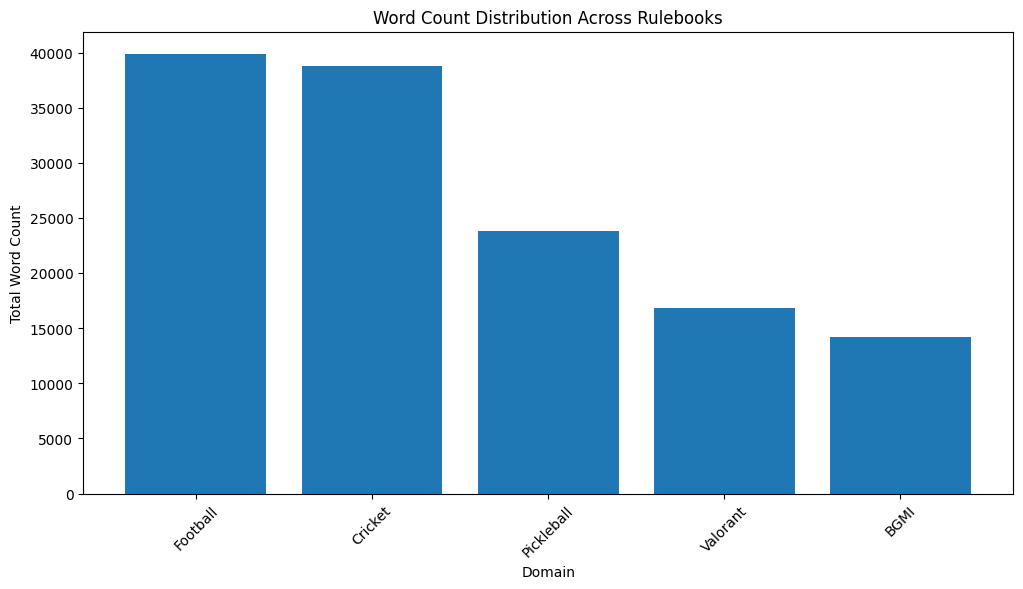

In [8]:
# Aggregate total words per domain
domain_word_counts = (

    df.groupby("domain")["word_count"]

    .sum()

    .sort_values(ascending=False)

)

# Visualization
plt.figure(figsize=(12,6))

plt.bar(

    domain_word_counts.index,

    domain_word_counts.values

)

plt.xticks(rotation=45)

plt.title(
    "Word Count Distribution Across Rulebooks"
)

plt.xlabel("Domain")

plt.ylabel("Total Word Count")

plt.show()

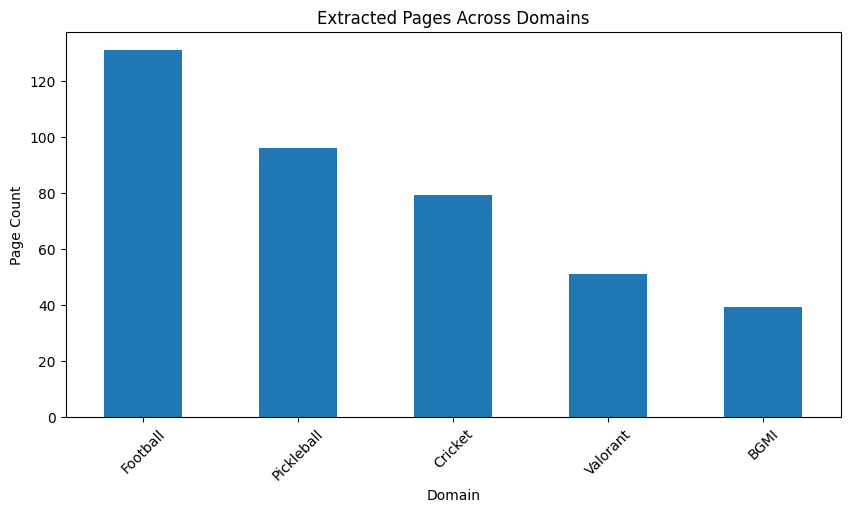

In [9]:
# Number of extracted pages per domain

df["domain"].value_counts().plot(

    kind="bar",

    figsize=(10,5)

)

plt.title(
    "Extracted Pages Across Domains"
)

plt.xlabel("Domain")

plt.ylabel("Page Count")

plt.xticks(rotation=45)

plt.show()

### Observations

The extracted corpus shows noticeable variation in document lengths across different sports and esports domains. Larger rulebooks contribute significantly more textual content, which can later influence retrieval behavior and embedding distributions.

# 3. Text Preprocessing Pipeline

# 3.1 Text Cleaning Pipeline

The extracted rulebook text contains inconsistent formatting, special symbols, and PDF extraction artifacts. This stage standardizes the corpus while preserving important sports and esports terminology.

Clean preprocessing improves retrieval consistency and semantic matching quality.

In [10]:
# Basic text cleaning

def basic_text_cleaning(text):

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    return text.strip()


# Normalize extracted symbols

def normalize_symbols(text):

    text = text.replace(
        "\n",
        " "
    )

    text = text.replace(
        "\t",
        " "
    )

    return text

In [11]:
# Apply text cleaning pipeline

df["cleaned_text"] = df["raw_text"].apply(
    basic_text_cleaning
)

df["cleaned_text"] = df[
    "cleaned_text"
].apply(
    normalize_symbols
)

df[[
    "domain",
    "cleaned_text"
]].head()

,domain,cleaned_text
0,BGMI,battlegrounds mobile india official competitio...
1,BGMI,battlegrounds mobile india official competitio...
2,BGMI,battlegrounds mobile india official competitio...
3,BGMI,battlegrounds mobile india official competitio...
4,BGMI,battlegrounds mobile india official competitio...


### Observations

The cleaning pipeline removes extraction artifacts while preserving important procedural terminology. The cleaned corpus now provides a more consistent representation for downstream retrieval tasks.

# 3.2 Text Normalization

Normalization standardizes textual representations across the rulebook corpus. This improves retrieval consistency while preserving semantically important gameplay terminology.

In [12]:
# Normalize text

def normalize_text(text):

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [13]:
# Apply normalization pipeline

df["normalized_text"] = df[
    "cleaned_text"
].apply(
    normalize_text
)

df[[
    "domain",
    "normalized_text"
]].head()

,domain,normalized_text
0,BGMI,battlegrounds mobile india official competitio...
1,BGMI,battlegrounds mobile india official competitio...
2,BGMI,battlegrounds mobile india official competitio...
3,BGMI,battlegrounds mobile india official competitio...
4,BGMI,battlegrounds mobile india official competitio...


### Observations

The normalization stage improves textual consistency across multiple rulebooks while preserving important domain-specific terminology required for retrieval.

# 3.3. Tokenization Pipeline

Tokenization divides raw text into smaller linguistic units such as words and sentences.

This stage is essential for: linguistic analysis, TF-IDF retrieval, FastText embedding generation, syntax-aware analysis

Tokenization becomes particularly important in esports domains where abbreviated terminology and tactical jargon are common.

In [14]:
nltk.download('punkt_tab')
# Tokenize normalized text

df["tokens"] = df[
    "normalized_text"
].apply(
    word_tokenize
)

df[[
    "domain",
    "tokens"
]].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,domain,tokens
0,BGMI,"[battlegrounds, mobile, india, official, compe..."
1,BGMI,"[battlegrounds, mobile, india, official, compe..."
2,BGMI,"[battlegrounds, mobile, india, official, compe..."
3,BGMI,"[battlegrounds, mobile, india, official, compe..."
4,BGMI,"[battlegrounds, mobile, india, official, compe..."


### Observations

The tokenization pipeline converts rulebook text into structured lexical units that later support sparse retrieval, semantic embeddings, and linguistic analysis.

# 3.4 Stopword Handling

Selective stopword handling is used to preserve procedurally important terms such as modal verbs and gameplay restrictions. This prevents semantic information loss during preprocessing.

In [15]:

# Load stopwords

custom_stopwords = set(
    stopwords.words("english")
)

# Preserve important procedural terms

important_terms = {

    "not",
    "no",
    "must",
    "shall",
    "cannot"

}

custom_stopwords = custom_stopwords - important_terms


# Remove unnecessary stopwords

df["filtered_tokens"] = df[
    "tokens"
].apply(

    lambda tokens: [

        token for token in tokens

        if token not in custom_stopwords

    ]

)

df[[
    "domain",
    "filtered_tokens"
]].head()

,domain,filtered_tokens
0,BGMI,"[battlegrounds, mobile, india, official, compe..."
1,BGMI,"[battlegrounds, mobile, india, official, compe..."
2,BGMI,"[battlegrounds, mobile, india, official, compe..."
3,BGMI,"[battlegrounds, mobile, india, official, compe..."
4,BGMI,"[battlegrounds, mobile, india, official, compe..."


### Observations

Selective stopword handling preserves important procedural language while reducing lexical noise. This improves retrieval quality without damaging rule semantics.

# 3.5 Lemmatization Pipeline

Lemmatization reduces words to their base forms while preserving grammatical meaning. This improves lexical consistency across rulebook documents and retrieval queries.

In [16]:
# Initialize lemmatizer

lemmatizer = WordNetLemmatizer()

# Reconstruct processed text

def reconstruct_text(tokens):

    return " ".join(tokens)
# Apply lemmatization

df["lemmatized_tokens"] = df[
    "filtered_tokens"
].apply(

    lambda tokens: [

        lemmatizer.lemmatize(token)

        for token in tokens

    ]

)

df[[
    "domain",
    "lemmatized_tokens"
]].head()

,domain,lemmatized_tokens
0,BGMI,"[battleground, mobile, india, official, compet..."
1,BGMI,"[battleground, mobile, india, official, compet..."
2,BGMI,"[battleground, mobile, india, official, compet..."
3,BGMI,"[battleground, mobile, india, official, compet..."
4,BGMI,"[battleground, mobile, india, official, compet..."


### Observations

The lemmatization stage improves lexical standardization while preserving contextual meaning. This later improves both sparse retrieval consistency and semantic embedding quality.

In [17]:
# Reconstruct processed text

def reconstruct_text(tokens):

    return " ".join(tokens)


# Generate processed retrieval text

df["processed_text"] = df[
    "lemmatized_tokens"
].apply(
    reconstruct_text
)

# Preview reconstructed text

df[[
    "domain",
    "processed_text"
]].head()

,domain,processed_text
0,BGMI,battleground mobile india official competition...
1,BGMI,battleground mobile india official competition...
2,BGMI,battleground mobile india official competition...
3,BGMI,battleground mobile india official competition...
4,BGMI,battleground mobile india official competition...


# 3.6 spaCy Linguistic Setup

spaCy is used for syntax-aware linguistic analysis including POS tagging, dependency parsing, and modal verb extraction. These components later improve explainability and contextual interpretation.

In [18]:
# Load English spaCy model

nlp = spacy.load(
    "en_core_web_sm"
)

print("spaCy model loaded successfully.")

spaCy model loaded successfully.


### Observations

The spaCy pipeline enables syntax-aware linguistic analysis across rulebook text. These components later support explainability and contextual retrieval interpretation.

# 4. Syntax-Aware Linguistic Analysis for Queries

# 4.1 Query Linguistic Processing

To improve semantic disambiguation and retrieval relevance, the project performs syntax-aware linguistic analysis on user queries before retrieval. Instead of relying only on raw lexical overlap, the system identifies gameplay entities, procedural actions, restrictions, and contextual keywords from the query itself.

This preprocessing stage helps reduce noisy retrieval behavior and improves contextual understanding across overlapping sports and esports terminology.

In [19]:
# Process user query using spaCy

def process_query(query):

    return nlp(query)

### Observations

POS tagging clearly identifies procedural structures within gameplay rules. Verbs such as “plant” and modal restrictions such as “cannot” become particularly important because they directly influence gameplay legality and rule interpretation.

# 4.2 POS-Based Query Decomposition

The retrieval system extracts important grammatical components from user queries using Part-of-Speech tagging. Gameplay entities, actions, and procedural restrictions are separated to improve retrieval focus and contextual interpretation.

In [20]:
# Extract gameplay entities

def extract_nouns(doc):

    return [

        token.text

        for token in doc

        if token.pos_ == "NOUN"

    ]

In [21]:
# Extract gameplay actions

def extract_verbs(doc):

    return [

        token.text

        for token in doc

        if token.pos_ == "VERB"

    ]

In [22]:
# Extract modal verbs

def extract_modal_verbs(doc):

    return [

        token.text

        for token in doc

        if token.tag_ == "MD"

    ]

### Observations

The extracted nouns and verbs capture the core semantic structure of the rule statement. Gameplay entities such as “spike” and procedural actions such as “plant” become easier to interpret through linguistic decomposition.

# 4.3 Query Decomposition

After extracting linguistic components, the query is decomposed into gameplay entities, procedural actions, and restrictive terms. This decomposition helps generate retrieval-focused semantic representations from natural language queries.

In [23]:
def analyze_query(query):

    doc = process_query(query)

    nouns = [

        token.text

        for token in doc

        if token.pos_ == "NOUN"

    ]

    verbs = [

        token.text

        for token in doc

        if token.pos_ == "VERB"

    ]

    modal_verbs = [

        token.text

        for token in doc

        if token.tag_ == "MD"

    ]

    # Safer retrieval keywords

    keywords = [

        token.text

        for token in doc

        if token.is_alpha
        and not token.is_stop

    ]

    return {

        "doc": doc,

        "nouns": nouns,

        "verbs": verbs,

        "modal_verbs": modal_verbs,

        "keywords": keywords

    }

# 4.4 Query Refinement for Retrieval

The extracted linguistic components are used to generate a refined retrieval query focused primarily on gameplay entities and procedural actions. This reduces noisy lexical information and improves semantic retrieval precision across ambiguity-heavy rulebook domains.

In [24]:
# Generate refined retrieval query

def refine_query(query):

    analysis = analyze_query(query)

    refined_query = " ".join(

        analysis["keywords"]

    )

    return refined_query

# 4.5 Retrieval-Oriented Query Analysis

The final query representation combines syntax-aware linguistic decomposition with retrieval-focused query refinement. This allows the retrieval system to focus primarily on gameplay entities, procedural actions, and contextual gameplay terminology rather than noisy natural language structure.

In [25]:
query = """

Can a substitute join
during an active round?

"""

query_analysis = analyze_query(
    query
)

query_analysis

{'doc': 
 
 Can a substitute join
 during an active round?
 ,
 'nouns': ['join', 'round'],
 'verbs': [],
 'modal_verbs': ['Can'],
 'keywords': ['substitute', 'join', 'active', 'round']}

In [26]:
refined_query = refine_query(
    query
)

print("Refined Query:")

print(refined_query)

Refined Query:
substitute join active round


# 5. Retrieval Preparation Pipeline

# 5.1 Retrieval Preparation Overview

Before retrieval can be performed, the rulebook corpus must be transformed into retrieval-friendly textual representations. Different retrieval systems require different preprocessing strategies depending on whether they rely on sparse lexical overlap or dense semantic embeddings.

This stage prepares the corpus for chunking, vectorization, semantic indexing, and hybrid retrieval while preserving important gameplay terminology and procedural semantics.

# 5.2 TF-IDF Preprocessing

Sparse retrieval systems such as TF-IDF perform best when lexical structure is highly standardized. Earlier preprocessing stages already applied cleaning, stopword removal, normalization, and lemmatization to reduce lexical variation across the rulebook corpus.

The processed textual representation generated during preprocessing is therefore reused directly for sparse retrieval preparation.

In [27]:
# Use processed text for TF-IDF retrieval

df["tfidf_text"] = df[
    "processed_text"
]

# Preview sparse retrieval text

df[[
    "domain",
    "tfidf_text"
]].head()

,domain,tfidf_text
0,BGMI,battleground mobile india official competition...
1,BGMI,battleground mobile india official competition...
2,BGMI,battleground mobile india official competition...
3,BGMI,battleground mobile india official competition...
4,BGMI,battleground mobile india official competition...


### Observations

The TF-IDF representation now uses aggressively normalized and lemmatized textual data generated during earlier preprocessing stages. This improves sparse retrieval consistency and reduces lexical noise across rulebook documents.

# 5.3 Embedding Preprocessing

Dense semantic embedding models require richer contextual structure compared to sparse lexical retrieval systems. Excessive preprocessing can damage semantic relationships and reduce embedding quality.

To preserve contextual meaning, the embedding pipeline uses lightly cleaned textual representations while avoiding aggressive lexical reduction.

In [28]:
# Use cleaned text for embedding retrieval

df["embedding_text"] = df[
    "cleaned_text"
]

# Preview embedding text

df[[
    "domain",
    "embedding_text"
]].head()

,domain,embedding_text
0,BGMI,battlegrounds mobile india official competitio...
1,BGMI,battlegrounds mobile india official competitio...
2,BGMI,battlegrounds mobile india official competitio...
3,BGMI,battlegrounds mobile india official competitio...
4,BGMI,battlegrounds mobile india official competitio...


### Observations

The embedding representation preserves contextual sentence structure while applying lightweight normalization. This improves semantic representation quality for dense vector retrieval and similarity search.

# 5.4 Retrieval Text Reconstruction

Earlier preprocessing stages reconstructed the processed token sequences into retrieval-ready textual representations. These reconstructed texts now serve as the primary inputs for sparse retrieval, dense embeddings, and chunk generation.

In [29]:
# Preview retrieval-ready text

df[[
    "domain",
    "processed_text",
    "embedding_text"
]].head()

,domain,processed_text,embedding_text
0,BGMI,battleground mobile india official competition...,battlegrounds mobile india official competitio...
1,BGMI,battleground mobile india official competition...,battlegrounds mobile india official competitio...
2,BGMI,battleground mobile india official competition...,battlegrounds mobile india official competitio...
3,BGMI,battleground mobile india official competition...,battlegrounds mobile india official competitio...
4,BGMI,battleground mobile india official competition...,battlegrounds mobile india official competitio...


# 5.5 Chunking Pipeline

Large rulebook documents cannot be indexed efficiently as single textual units. Therefore, the corpus is divided into smaller semantically manageable chunks that preserve contextual coherence while improving retrieval granularity.

The chunking strategy plays a major role in retrieval precision, semantic relevance, and ambiguity handling quality across multiple domains.

In [30]:
# Split text into retrieval chunks

def chunk_text(text, chunk_size=150):

    words = text.split()

    chunks = []

    for i in range(

        0,

        len(words),

        chunk_size

    ):

        chunk = " ".join(

            words[i:i + chunk_size]

        )

        chunks.append(chunk)

    return chunks

In [31]:
# Generate chunked corpus

chunked_documents = []

for idx, row in df.iterrows():

    chunks = chunk_text(

        row["embedding_text"]

    )

    for chunk_id, chunk in enumerate(chunks):

        chunked_documents.append({

            "domain": row["domain"],

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "chunk_id": chunk_id,

            "chunk": chunk

        })

In [32]:
# Create chunk dataframe

chunk_df = pd.DataFrame(
    chunked_documents
)

print("Total Chunks:")

print(len(chunk_df))

Total Chunks:
1138


In [33]:
# Preview generated chunks

chunk_df[[
    "domain",
    "chunk_id",
    "chunk"
]].head()

,domain,chunk_id,chunk
0,BGMI,0,battlegrounds mobile india official competitio...
1,BGMI,0,battlegrounds mobile india official competitio...
2,BGMI,1,2 initial red flag list 14 5 3 decisions relat...
3,BGMI,0,battlegrounds mobile india official competitio...
4,BGMI,1,submission 30 14 5 remake limits 30 14 6 strea...


### Observations

The chunking pipeline converts large rulebook documents into smaller retrieval-friendly textual segments. Proper chunking improves retrieval granularity while preserving contextual coherence across gameplay rules and procedural statements.

# 5.6 Chunk Metadata Construction

Each retrieval chunk preserves important metadata including domain labels, source files, page numbers, and chunk identifiers. Metadata preservation improves explainability, source tracing, and domain-aware retrieval behavior.

In [34]:
# Preview retrieval metadata

chunk_df[[
    "domain",
    "source_file",
    "page_number",
    "chunk_id"
]].head()

,domain,source_file,page_number,chunk_id
0,BGMI,BGMI.pdf,1,0
1,BGMI,BGMI.pdf,2,0
2,BGMI,BGMI.pdf,2,1
3,BGMI,BGMI.pdf,3,0
4,BGMI,BGMI.pdf,3,1


# 5.7 Chunk Quality Filtering

Some extracted chunks may contain low-information fragments, extraction artifacts, or extremely short textual sequences. Filtering noisy chunks improves retrieval precision and reduces semantic confusion during similarity search.

In [35]:
# Remove extremely small chunks

chunk_df = chunk_df[

    chunk_df["chunk"].str.split().apply(len) > 15

].reset_index(drop=True)

print("Filtered Chunks:")

print(len(chunk_df))

Filtered Chunks:
1093


# 6. Domain-Aware Retrieval Routing

# 6.1 Domain Routing Overview

Many gameplay terms overlap heavily across sports and esports domains. Terms such as “round”, “zone”, “attack”, and “block” may represent entirely different procedural meanings depending on contextual usage.

To reduce semantic ambiguity and noisy retrieval behavior, the retrieval pipeline first predicts the most likely gameplay domain associated with a user query before performing retrieval operations.

# 6.2 Domain Hint Construction

The domain routing system uses domain-specific gameplay terminology to identify contextual associations between user queries and rulebook domains. These gameplay hints act as lightweight semantic routing signals before retrieval is performed.

In [36]:
DOMAIN_HINTS = {

   "Valorant": [
    "valorant",
    "agent",
    "spike",
    "defuse",
    "round",
    "map",
    "disconnect",
    "timeout",
    "tactical"

    ],

    "BGMI": [
    "bgmi",
    "battle royale",
    "zone",
    "roster",
    "survival",
    "drop",
    "team",
    "circle"
    ],

    "Football": [

        "Football",
        "goal",
        "offside",
        "shot",
        "penalty",
        "kick"

    ],

    "Cricket": [

        "Cricket",
        "wicket",
        "fielder",
        "umpire",
        "innings",
        "bowler"

    ],

    "Pickleball": [

        "Pickleball",
        "serve",
        "kitchen",
        "paddle",
        "volley"

    ]
}

# 6.3 Query Domain Detection

The retrieval system predicts the most likely gameplay domain associated with a user query using lightweight lexical domain scoring. This stage narrows the retrieval search space before sparse or dense retrieval is performed.

Domain-aware routing significantly improves semantic disambiguation and reduces noisy cross-domain retrieval behavior.

In [37]:
# Predict likely gameplay domain

def detect_query_domain(query):

    query = query.lower()

    domain_scores = {}

    for domain, keywords in DOMAIN_HINTS.items():

        score = 0

        for keyword in keywords:

            if keyword in query:

                score += 1

        domain_scores[domain] = score

    predicted_domain = max(

        domain_scores,

        key=domain_scores.get

    )

    return predicted_domain

# 6.4 Domain-Aware Retrieval Filtering

After predicting the gameplay domain associated with a query, retrieval operations are restricted primarily to chunks belonging to the predicted domain. This filtering mechanism reduces semantic overlap and improves retrieval precision across ambiguity-heavy procedural terminology.

In [38]:
# Filter chunks by predicted domain

def filter_chunks_by_domain(query):

    predicted_domain = detect_query_domain(
        query
    )

    filtered_chunks = chunk_df[

        chunk_df["domain"] == predicted_domain

    ]

    return filtered_chunks

# 6.5 Domain Routing Testing

The domain routing pipeline is evaluated using ambiguity-heavy gameplay queries spanning multiple sports and esports domains. This helps analyze contextual disambiguation behavior and domain prediction quality before retrieval.

In [39]:
# Test queries across sports and esports domains
test_queries = [

    # Valorant
    "Can a player plant the spike after the timer expires?",

    # BGMI
    "What happens if a player stays outside the safe zone?",

    # Football
    "Can a goal be scored directly from a free kick?",

    # Cricket
    "Why can a bowler not bowl two consecutive overs?",

    # Pickleball
    "Can a player volley inside the kitchen area?",

    # Ambiguous cross-domain query
    "Can players shoot through smoke?"

]

for query in test_queries:

    predicted_domain = detect_query_domain(
        query
    )

    print("=" * 60)

    print("QUERY:")

    print(query)

    print("\nPredicted Domain:")

    print(predicted_domain)

    print("=" * 60)

    print("\n")

QUERY:
Can a player plant the spike after the timer expires?

Predicted Domain:
Valorant


QUERY:
What happens if a player stays outside the safe zone?

Predicted Domain:
BGMI


QUERY:
Can a goal be scored directly from a free kick?

Predicted Domain:
Football


QUERY:
Why can a bowler not bowl two consecutive overs?

Predicted Domain:
Cricket


QUERY:
Can a player volley inside the kitchen area?

Predicted Domain:
Pickleball


QUERY:
Can players shoot through smoke?

Predicted Domain:
Valorant




### Observations

Domain-aware routing significantly improves semantic disambiguation by narrowing the retrieval search space before sparse or dense similarity search is performed. This reduces noisy cross-domain retrieval behavior and improves contextual relevance across overlapping gameplay terminology.

In [40]:
# Preprocess retrieval queries

def preprocess_query(query):

    query = query.lower()

    query = re.sub(

        r"[^a-zA-Z0-9\s]",

        " ",

        query

    )

    query = re.sub(

        r"\s+",

        " ",

        query

    )

    return query.strip()

# 7. Sparse Retrieval Pipeline

# 7.1 Sparse Retrieval Overview

Sparse retrieval systems rely primarily on lexical overlap and keyword frequency statistics to identify relevant textual matches between user queries and indexed rulebook chunks. TF-IDF retrieval performs particularly well for explicit procedural terminology and keyword-heavy gameplay queries.

This stage constructs a domain-aware sparse retrieval pipeline using TF-IDF vectorization and cosine similarity search across the chunked rulebook corpus.

# 7.2 TF-IDF Vectorization

The chunked rulebook corpus is transformed into sparse numerical vectors using TF-IDF vectorization. This representation captures term importance while reducing the influence of extremely common lexical patterns.

The resulting sparse matrix enables efficient lexical similarity search across gameplay rules and procedural statements.

In [41]:
# Initialize TF-IDF vectorizer

tfidf_vectorizer = TfidfVectorizer(

    ngram_range=(1,2),

    max_features=5000

)

# Generate sparse TF-IDF matrix

tfidf_matrix = tfidf_vectorizer.fit_transform(

    chunk_df["chunk"]

)

print("TF-IDF Matrix Shape:")

print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(1093, 5000)


### Observations

The TF-IDF vectorization stage converts the chunked rulebook corpus into sparse lexical representations suitable for similarity-based retrieval. The sparse matrix captures important procedural terminology and gameplay-specific lexical patterns.

# 7.3 Sparse Similarity Search

Sparse retrieval is performed by comparing the vectorized user query against the TF-IDF representations of indexed rulebook chunks. Cosine similarity is used to identify lexically similar procedural statements and gameplay rules.

# 7.4 Domain-Aware TF-IDF Retrieval

Before sparse retrieval is performed, the retrieval pipeline first predicts the most likely gameplay domain associated with the query. Retrieval is then restricted primarily to chunks belonging to the predicted domain.

This domain-aware filtering mechanism significantly improves semantic disambiguation and reduces noisy cross-domain retrieval behavior.

In [42]:
# Perform domain-aware TF-IDF retrieval

def tfidf_search(query, top_k=5):

    predicted_domain = detect_query_domain(
        query
    )

    processed_query = preprocess_query(
        query
    )

    filtered_chunks = chunk_df[

        chunk_df["domain"] == predicted_domain

    ].copy()

    # Preserve original matrix indices

    filtered_chunks = filtered_chunks.reset_index(
        drop=False
    )

    filtered_matrix = tfidf_matrix[
        filtered_chunks["index"].values,
        :
    ]

    query_vector = tfidf_vectorizer.transform(
        [processed_query]
    )

    similarity_scores = cosine_similarity(

        query_vector,

        filtered_matrix

    ).flatten()

    top_indices = similarity_scores.argsort()[::-1][:top_k]

    results = filtered_chunks.iloc[
        top_indices
    ].copy()

    results["score"] = similarity_scores[
        top_indices
    ]

    return results

# 7.5 Top-K Retrieval

The sparse retrieval system ranks rulebook chunks according to cosine similarity scores and returns the top-K most relevant procedural matches. This enables focused retrieval of gameplay rules relevant to the user query.

In [43]:
query = """

Can a substitute join
during an active round?

"""

tfidf_results = tfidf_search(
    query
)

tfidf_results[[
    "domain",
    "score",
    "chunk"
]]

,domain,score,chunk
78,Valorant,0.217910,round rollbacks may be used for unintended exp...
88,Valorant,0.214121,occur after a player s agent has been eliminat...
69,Valorant,0.212094,if at the time that a bug occurs in a round no...
105,Valorant,0.183726,restore the round for all other interruptions ...
89,Valorant,0.181665,for all other interruptions to gameplay both t...


# 7.6 Sparse Retrieval Testing

The sparse retrieval pipeline is evaluated using ambiguity-heavy gameplay queries spanning multiple sports and esports domains. This helps analyze lexical retrieval quality, procedural matching behavior, and domain-aware ambiguity handling.

In [44]:
test_queries = [

    # Valorant
    "Can a player plant the spike after the timer expires?",

    # BGMI
    "What happens if a player stays outside the safe zone?",

    # Football
    "Can a goal be scored directly from a free kick?",

    # Cricket
    "Why can a bowler not bowl two consecutive overs?",

    # Pickleball
    "Can a player volley inside the kitchen area?",

    # Ambiguous cross-domain query
    "Can players shoot through smoke?"

]

In [45]:
for query in test_queries:

    print("=" * 70)

    print("QUERY:")

    print(query)

    print("\nPredicted Domain:")

    print(
        detect_query_domain(query)
    )

    print("\nTop Retrieval Results:")

    results = tfidf_search(query)

    display(

        results[[
            "domain",
            "score",
            "chunk"
        ]]

    )

    print("\n")

QUERY:
Can a player plant the spike after the timer expires?

Predicted Domain:
Valorant

Top Retrieval Results:


,domain,score,chunk
50,Valorant,0.188868,process will be restarted with the same picks ...
52,Valorant,0.158991,maps provided that the team informs the opposi...
116,Valorant,0.124580,be split into two subgroups the top team s and...
78,Valorant,0.113002,round rollbacks may be used for unintended exp...
60,Valorant,0.109831,teams are allowed to call timeouts of sixty 60...




QUERY:
What happens if a player stays outside the safe zone?

Predicted Domain:
BGMI

Top Retrieval Results:


,domain,score,chunk
82,BGMI,0.100539,a tournament game for any reason even if the i...
86,BGMI,0.072736,battlegrounds mobile india official competitio...
83,BGMI,0.070947,battlegrounds mobile india official competitio...
12,BGMI,0.067566,battlegrounds mobile india official competitio...
81,BGMI,0.065670,yellow or mobile phone stuttering or critical ...




QUERY:
Can a goal be scored directly from a free kick?

Predicted Domain:
Football

Top Retrieval Results:


...

,domain,score,chunk
93,Cricket,0.249528,interruption it shall be completed on resumpti...
92,Cricket,0.245186,laws of cricket 2017 code 3rd edition 2022 25 ...
71,Cricket,0.187477,laws of cricket 2017 code 3rd edition 2022 20 ...
257,Cricket,0.177909,2 2 together the umpires shall summon and info...
231,Cricket,0.168348,for this action the bowler thus suspended shal...




QUERY:
Can a player volley inside the kitchen area?

Predicted Domain:
Pickleball

Top Retrieval Results:


,domain,score,chunk
30,Pickleball,0.271148,more than 1 0 inch 2 54 cm above the top of th...
14,Pickleball,0.215729,motion or stops moving toward the non volley z...
66,Pickleball,0.185727,to exit the non volley zone before volleying a...
65,Pickleball,0.177649,25 2026 usa pickleball official rulebook copyr...
172,Pickleball,0.175672,is a fault against the volleying player modifi...




QUERY:
Can players shoot through smoke?

Predicted Domain:
Valorant

Top Retrieval Results:


,domain,score,chunk
66,Valorant,0.092810,7 bugs 7 1 types of bugs a bug is an error fla...
85,Valorant,0.066651,the challenge is unsuccessful the team s one c...
73,Valorant,0.057215,to be indestructible and or unviewable by the ...
63,Valorant,0.055579,players are not allowed to leave the match are...
110,Valorant,0.051701,5 1 3 between maps league officials will infor...


# 7.7 Sparse Retrieval Analysis

The sparse retrieval pipeline demonstrates strong performance for keyword-heavy gameplay queries and explicit procedural terminology. Domain-aware filtering significantly improves semantic disambiguation by restricting retrieval to contextually relevant gameplay domains.

However, TF-IDF retrieval still relies primarily on lexical overlap and may struggle with paraphrased queries, synonym-heavy procedural statements, and deeper contextual reasoning tasks.

In [46]:
sparse_analysis = pd.DataFrame({

    "Strengths": [

        "Strong keyword matching",

        "Good procedural rule retrieval",

        "Fast retrieval speed",

        "Effective lexical similarity search",

        "Improved domain-aware filtering"

    ],

    "Weaknesses": [

        "Weak semantic understanding",

        "Poor synonym handling",

        "Limited contextual reasoning",

        "Sensitive to query wording",

        "May fail on paraphrased queries"

    ]

})

sparse_analysis

,Strengths,Weaknesses
0,Strong keyword matching,Weak semantic understanding
1,Good procedural rule retrieval,Poor synonym handling
2,Fast retrieval speed,Limited contextual reasoning
3,Effective lexical similarity search,Sensitive to query wording
4,Improved domain-aware filtering,May fail on paraphrased queries


## Transition to Dense Semantic Retrieval

While sparse retrieval performs well for lexical overlap and procedural terminology, it struggles with semantic paraphrasing and contextual similarity. To address these limitations, the next stage introduces dense semantic retrieval using embedding-based vector representations.

Dense retrieval improves semantic understanding by capturing contextual relationships between gameplay concepts beyond simple keyword overlap.

# 8. Dense Semantic Retrieval

# 8.1 Dense Retrieval Overview

Unlike sparse retrieval systems that rely primarily on lexical overlap, dense semantic retrieval represents text as continuous numerical embeddings that capture contextual meaning and semantic similarity.

Dense retrieval improves retrieval quality for paraphrased gameplay queries, synonym-heavy procedural rules, and semantically ambiguous cross-domain terminology.

# 8.2 GloVe Embedding Setup

The dense retrieval pipeline uses GloVe embeddings to generate semantic vector representations for gameplay rules and user queries. Unlike traditional word embeddings, GloVe incorporates subword information, making it more robust for domain-specific procedural terminology and uncommon gameplay vocabulary.

In [47]:
fasttext_model = api.load(
    "glove-wiki-gigaword-100"
)

[==================================================] 100.0% 128.1/128.1MB downloaded


# 8.3 Chunk Embedding Generation

Each retrieval chunk is transformed into a dense semantic vector representation using FastText embeddings. The chunk embedding is generated by averaging the word embeddings present within the chunk text.

These dense representations later enable semantic similarity search across gameplay rules and procedural statements.

In [48]:
# Generate embedding representation for text

def get_text_embedding(text):

    words = text.split()

    word_vectors = []

    for word in words:

        if word in fasttext_model:

            word_vectors.append(
                fasttext_model[word]
            )

    # Handle empty vectors

    if len(word_vectors) == 0:

        return np.zeros(300)

    # Average word embeddings

    return np.mean(
        word_vectors,
        axis=0
    )

In [49]:
# Generate dense embeddings for retrieval chunks

chunk_embeddings = np.array(

    chunk_df["chunk"].apply(
        get_text_embedding
    ).tolist()

)

print("Chunk Embedding Shape:")

print(chunk_embeddings.shape)

Chunk Embedding Shape:
(1093, 100)


### Observations

The dense embedding pipeline transforms gameplay rules into continuous semantic vector representations. Unlike sparse lexical retrieval, dense embeddings capture contextual similarity and semantic relationships between gameplay concepts.

# 8.4 Query Embedding Generation

User queries are transformed into dense semantic embeddings using the same FastText embedding pipeline. This enables direct semantic similarity comparison between user queries and rulebook chunks.

In [50]:
query = """

Can a substitute join
during an active round?

"""

query_embedding = get_text_embedding(
    query
)

print("Query Embedding Shape:")

print(query_embedding.shape)

Query Embedding Shape:
(100,)


In [51]:
# Perform dense semantic retrieval

def dense_search(query, top_k=5):

    # Predict gameplay domain

    predicted_domain = detect_query_domain(
        query
    )

    # Filter chunks by predicted domain

    filtered_chunks = chunk_df[

        chunk_df["domain"] == predicted_domain

    ]

    # Get filtered embeddings

    filtered_embeddings = chunk_embeddings[
        filtered_chunks.index
    ]

    # Generate query embedding

    query_embedding = get_text_embedding(
        query
    ).reshape(1, -1)

    # Compute cosine similarity

    similarity_scores = cosine_similarity(

        query_embedding,

        filtered_embeddings

    ).flatten()

    # Get top retrieval indices

    top_indices = similarity_scores.argsort()[::-1][:top_k]

    # Retrieve top chunks

    results = filtered_chunks.iloc[
        top_indices
    ].copy()

    # Attach similarity scores

    results["score"] = similarity_scores[
        top_indices
    ]

    return results

# 8.5 Dense Similarity Search

Dense retrieval compares semantic vector representations of user queries and rulebook chunks using cosine similarity. Unlike sparse lexical matching, semantic retrieval can identify procedurally similar gameplay rules even when exact keywords differ.

In [52]:
# Perform dense semantic retrieval

def dense_search(query, top_k=5):

    # Predict gameplay domain

    predicted_domain = detect_query_domain(
        query
    )

    # Filter chunks by predicted domain

    filtered_chunks = chunk_df[

        chunk_df["domain"] == predicted_domain

    ]

    # Get filtered embeddings

    filtered_embeddings = chunk_embeddings[
        filtered_chunks.index
    ]

    # Generate query embedding

    query_embedding = get_text_embedding(
        query
    ).reshape(1, -1)

    # Compute cosine similarity

    similarity_scores = cosine_similarity(

        query_embedding,

        filtered_embeddings

    ).flatten()

    # Get top retrieval indices

    top_indices = similarity_scores.argsort()[::-1][:top_k]

    # Retrieve top chunks

    results = filtered_chunks.iloc[
        top_indices
    ].copy()

    # Attach similarity scores

    results["score"] = similarity_scores[
        top_indices
    ]

    return results

# 8.6 Domain-Aware Dense Retrieval

Dense retrieval is combined with domain-aware query routing to reduce semantic confusion across overlapping sports and esports terminology. Restricting retrieval to the predicted gameplay domain improves contextual relevance and ambiguity handling quality.

# 8.7 Dense Retrieval Testing

The dense retrieval pipeline is evaluated using semantically complex gameplay queries involving paraphrasing, contextual overlap, and ambiguity-heavy procedural terminology.

In [53]:
for query in test_queries:

    print("=" * 70)

    print("QUERY:")

    print(query)

    print("\nPredicted Domain:")

    print(
        detect_query_domain(query)
    )

    print("\nTop Dense Retrieval Results:")

    results = dense_search(query)

    display(

        results[[
            "domain",
            "score",
            "chunk"
        ]]

    )

    print("\n")

QUERY:
Can a player plant the spike after the timer expires?

Predicted Domain:
Valorant

Top Dense Retrieval Results:


,domain,score,chunk
1024,Valorant,0.943482,if at the time that a bug occurs in a round no...
1043,Valorant,0.941102,occur after a player s agent has been eliminat...
1058,Valorant,0.936089,match has an issue that causes an interruption...
1005,Valorant,0.935204,process will be restarted with the same picks ...
1059,Valorant,0.933132,using the in game round restore feature to the...




QUERY:
What happens if a player stays outside the safe zone?

Predicted Domain:
BGMI

Top Dense Retrieval Results:


,domain,score,chunk
82,BGMI,0.929390,a tournament game for any reason even if the i...
47,BGMI,0.925622,2 10 spectator monitors devices team members m...
88,BGMI,0.924358,battlegrounds mobile india official competitio...
81,BGMI,0.921574,yellow or mobile phone stuttering or critical ...
83,BGMI,0.917514,battlegrounds mobile india official competitio...




QUERY:
Can a goal be scored directly from a free kick?

Predicted Domain:
Football

Top Dense Retrieval Results:


...

,domain,score,chunk
205,Cricket,0.932453,interruption it shall be completed on resumpti...
250,Cricket,0.929828,being a wide passes the striker without touchi...
213,Cricket,0.928429,obstruction of batter 18 10 crediting of runs ...
211,Cricket,0.927633,any runs for penalties awarded to either side ...
306,Cricket,0.927158,runs to the batting side return any not out ba...




QUERY:
Can a player volley inside the kitchen area?

Predicted Domain:
Pickleball

Top Dense Retrieval Results:


,domain,score,chunk
802,Pickleball,0.922495,to exit the non volley zone before volleying a...
908,Pickleball,0.919772,is a fault against the volleying player modifi...
907,Pickleball,0.900919,player does not return a ball before it bounce...
807,Pickleball,0.899179,a fault against the player 13 e ball under net...
801,Pickleball,0.898675,25 2026 usa pickleball official rulebook copyr...




QUERY:
Can players shoot through smoke?

Predicted Domain:
Valorant

Top Dense Retrieval Results:


,domain,score,chunk
1054,Valorant,0.875889,half the sixty second clock will begin when bo...
1016,Valorant,0.861307,are not allowed to leave the match area at any...
983,Valorant,0.855811,written or printed materials into the match ar...
1015,Valorant,0.855272,teams are allowed to call timeouts of sixty 60...
1006,Valorant,0.854790,all maps will be selected in accordance with t...


# 8.8 Dense Retrieval Analysis

Dense semantic retrieval significantly improves contextual understanding and semantic similarity matching compared to sparse lexical retrieval. The embedding-based retrieval pipeline performs particularly well for paraphrased gameplay queries, synonym-heavy procedural statements, and semantically ambiguous terminology.

However, dense retrieval may occasionally retrieve contextually broad chunks and may struggle with highly explicit procedural rule wording where sparse lexical overlap performs better.

In [54]:
dense_analysis = pd.DataFrame({

    "Strengths": [

        "Strong semantic understanding",

        "Handles paraphrased queries well",

        "Improved ambiguity handling",

        "Better contextual similarity matching",

        "Captures semantic relationships"

    ],

    "Weaknesses": [

        "Computationally heavier",

        "May retrieve broader context",

        "Less precise for exact keywords",

        "Embedding averaging loses structure",

        "Can introduce semantic noise"

    ]

})

dense_analysis

,Strengths,Weaknesses
0,Strong semantic understanding,Computationally heavier
1,Handles paraphrased queries well,May retrieve broader context
2,Improved ambiguity handling,Less precise for exact keywords
3,Better contextual similarity matching,Embedding averaging loses structure
4,Captures semantic relationships,Can introduce semantic noise


## Transition to FAISS Vector Search

While dense semantic retrieval improves contextual understanding and semantic similarity matching, direct similarity computation across large embedding collections becomes computationally expensive as corpus size increases.

To improve scalability and retrieval efficiency, the next stage introduces FAISS-based vector indexing for high-speed semantic similarity search across dense embedding representations.

# 9. FAISS Vector Search

# 9.1 FAISS Retrieval Overview

Dense semantic retrieval becomes computationally expensive when similarity comparisons must be performed across large embedding collections. FAISS (Facebook AI Similarity Search) provides highly efficient vector indexing and nearest-neighbor retrieval for dense semantic embeddings.

This stage introduces scalable vector similarity search across gameplay rule embeddings using FAISS indexing.

# 9.2 Vector Index Construction

Before indexing can be performed, the dense semantic embeddings are converted into FAISS-compatible numerical vector representations. The vector index later enables efficient semantic nearest-neighbor search across gameplay rule chunks.

In [55]:
# Convert embeddings to float32

chunk_embeddings = np.array(

    chunk_embeddings

).astype("float32")

print("Embedding Shape:")

print(chunk_embeddings.shape)

Embedding Shape:
(1093, 100)


# 9.3 FAISS Indexing

The dense semantic embeddings are indexed using a FAISS L2 similarity index. This allows efficient nearest-neighbor retrieval based on semantic vector similarity.

In [56]:
# Define embedding dimension

embedding_dimension = chunk_embeddings.shape[1]

# Create FAISS index

faiss_index = faiss.IndexFlatL2(
    embedding_dimension
)

# Add embeddings to index

faiss_index.add(
    chunk_embeddings
)

print("Total Indexed Vectors:")

print(faiss_index.ntotal)

Total Indexed Vectors:
1093


# 9.4 FAISS Similarity Search

FAISS performs nearest-neighbor vector search by comparing the semantic embedding of a user query against the indexed gameplay rule embeddings. The retrieval pipeline returns the most semantically similar gameplay rule chunks.

In [57]:
# Perform FAISS semantic retrieval

def faiss_search(query, top_k=5):

    # Predict gameplay domain

    predicted_domain = detect_query_domain(
        query
    )

    # Filter chunks by predicted domain

    filtered_chunks = chunk_df[

        chunk_df["domain"] == predicted_domain

    ]

    # Generate query embedding

    query_embedding = get_text_embedding(
        query
    ).astype("float32").reshape(1, -1)

    # Perform FAISS search

    distances, indices = faiss_index.search(

        query_embedding,

        top_k * 5

    )

    retrieved_indices = []

    for idx in indices[0]:

        if idx in filtered_chunks.index:

            retrieved_indices.append(idx)

        if len(retrieved_indices) == top_k:

            break

    # Retrieve matching chunks

    results = chunk_df.loc[
        retrieved_indices
    ].copy()

    # Add similarity distances

    results["score"] = distances[0][
        :len(results)
    ]

    return results

# 9.5 Domain-Aware FAISS Retrieval

FAISS retrieval is combined with domain-aware query routing to reduce semantic overlap across sports and esports gameplay terminology. This improves semantic precision and reduces noisy nearest-neighbor retrieval behavior.

# 9.6 FAISS Retrieval Testing

The FAISS retrieval pipeline is evaluated using semantically ambiguous gameplay queries involving procedural overlap, paraphrasing, and cross-domain terminology.

In [58]:
for query in test_queries:

    print("=" * 70)

    print("QUERY:")

    print(query)

    print("\nPredicted Domain:")

    print(
        detect_query_domain(query)
    )

    print("\nTop FAISS Retrieval Results:")

    results = faiss_search(query)

    display(

        results[[
            "domain",
            "score",
            "chunk"
        ]]

    )

    print("\n")

QUERY:
Can a player plant the spike after the timer expires?

Predicted Domain:
Valorant

Top FAISS Retrieval Results:


,domain,score,chunk
1024,Valorant,1.856376,if at the time that a bug occurs in a round no...
1043,Valorant,1.899479,occur after a player s agent has been eliminat...
1058,Valorant,1.909177,match has an issue that causes an interruption...
1005,Valorant,1.935833,process will be restarted with the same picks ...




QUERY:
What happens if a player stays outside the safe zone?

Predicted Domain:
BGMI

Top FAISS Retrieval Results:


,domain,score,chunk




QUERY:
Can a goal be scored directly from a free kick?

Predicted Domain:
Football

Top FAISS Retrieval Results:


...

,domain,score,chunk
205,Cricket,2.534554,interruption it shall be completed on resumpti...
250,Cricket,2.583258,being a wide passes the striker without touchi...
213,Cricket,2.636924,obstruction of batter 18 10 crediting of runs ...
306,Cricket,2.682250,runs to the batting side return any not out ba...
211,Cricket,2.685396,any runs for penalties awarded to either side ...




QUERY:
Can a player volley inside the kitchen area?

Predicted Domain:
Pickleball

Top FAISS Retrieval Results:


,domain,score,chunk
802,Pickleball,2.591183,to exit the non volley zone before volleying a...
908,Pickleball,2.732290,is a fault against the volleying player modifi...
907,Pickleball,3.275498,player does not return a ball before it bounce...
801,Pickleball,3.349886,25 2026 usa pickleball official rulebook copyr...
859,Pickleball,3.384071,49 2026 usa pickleball official rulebook copyr...




QUERY:
Can players shoot through smoke?

Predicted Domain:
Valorant

Top FAISS Retrieval Results:


,domain,score,chunk
1054,Valorant,4.000676,half the sixty second clock will begin when bo...


# 9.7 FAISS Retrieval Analysis

FAISS significantly improves semantic retrieval scalability by enabling efficient nearest-neighbor vector search across dense gameplay embeddings. The vector indexing pipeline improves retrieval speed while preserving semantic similarity behavior.

FAISS retrieval performs particularly well for semantically complex gameplay queries and scalable semantic retrieval tasks involving large embedding collections.

In [59]:
faiss_analysis = pd.DataFrame({

    "Strengths": [

        "Highly scalable retrieval",

        "Fast semantic search",

        "Efficient nearest-neighbor retrieval",

        "Strong semantic similarity matching",

        "Production-style vector indexing"

    ],

    "Weaknesses": [

        "Requires vector indexing",

        "More memory intensive",

        "Approximate retrieval tradeoffs",

        "Semantic noise possible",

        "Less interpretable than sparse retrieval"

    ]

})

faiss_analysis

,Strengths,Weaknesses
0,Highly scalable retrieval,Requires vector indexing
1,Fast semantic search,More memory intensive
2,Efficient nearest-neighbor retrieval,Approximate retrieval tradeoffs
3,Strong semantic similarity matching,Semantic noise possible
4,Production-style vector indexing,Less interpretable than sparse retrieval


## Transition to Hybrid Retrieval

Sparse retrieval performs well for explicit lexical overlap and procedural terminology, while dense semantic retrieval improves contextual understanding and paraphrase handling. FAISS further improves semantic retrieval scalability through vector indexing.

The next stage combines sparse and dense retrieval techniques into a unified hybrid retrieval pipeline that balances lexical precision with semantic understanding.

# 10. Hybrid Retrieval Pipeline

# 10.1 Hybrid Retrieval Overview

Sparse retrieval performs well for explicit lexical overlap and procedural terminology, while dense semantic retrieval improves contextual understanding and semantic similarity matching. Hybrid retrieval combines both approaches to balance lexical precision with semantic reasoning.

This stage constructs a unified retrieval pipeline by combining sparse TF-IDF similarity and dense semantic retrieval scores.

# 10.2 Sparse and Dense Retrieval Fusion

The hybrid retrieval system combines sparse lexical similarity scores with dense semantic similarity scores to improve retrieval robustness across ambiguity-heavy gameplay queries.

This fusion mechanism improves contextual retrieval quality while preserving explicit procedural terminology matching.

In [60]:
# Normalize similarity scores

def normalize_scores(scores):

    scores = np.array(scores)

    if scores.max() == scores.min():

        return np.zeros_like(scores)

    return (

        scores - scores.min()

    ) / (

        scores.max() - scores.min()

    )

# 10.3 Hybrid Similarity Scoring

Sparse and dense similarity scores are normalized and combined into a unified hybrid relevance score. This enables the retrieval system to simultaneously leverage lexical precision and semantic contextual understanding.

In [61]:
# Perform hybrid retrieval

def hybrid_search(query, top_k=5):

    # Predict gameplay domain

    predicted_domain = detect_query_domain(
        query
    )

    # Filter chunks by domain

    filtered_chunks = chunk_df[

        chunk_df["domain"] == predicted_domain

    ]

    filtered_indices = filtered_chunks.index

    # Sparse Retrieval

    processed_query = preprocess_query(
        query
    )

    query_vector = tfidf_vectorizer.transform(
        [processed_query]
    )

    filtered_tfidf_matrix = tfidf_matrix[
        filtered_indices,
        :
    ]

    sparse_scores = cosine_similarity(

        query_vector,

        filtered_tfidf_matrix

    ).flatten()

    # Dense Retrieval
    query_embedding = get_text_embedding(
        query
    ).reshape(1, -1)

    filtered_embeddings = chunk_embeddings[
        filtered_indices
    ]

    dense_scores = cosine_similarity(

        query_embedding,

        filtered_embeddings

    ).flatten()


    # Score Normalization
    sparse_scores = normalize_scores(
        sparse_scores
    )

    dense_scores = normalize_scores(
        dense_scores
    )


    # Hybrid Score Fusion
    hybrid_scores = (

        0.5 * sparse_scores +

        0.5 * dense_scores

    )


    # Retrieve Top Results
    top_indices = hybrid_scores.argsort()[::-1][:top_k]

    results = filtered_chunks.iloc[
        top_indices
    ].copy()

    results["sparse_score"] = sparse_scores[
        top_indices
    ]

    results["dense_score"] = dense_scores[
        top_indices
    ]

    results["hybrid_score"] = hybrid_scores[
        top_indices
    ]

    return results

# 10.4 Hybrid Reranking

The hybrid retrieval system reranks gameplay rule chunks using combined sparse and dense relevance scores. This reranking mechanism improves semantic precision while preserving explicit procedural terminology matching.

# 10.5 Hybrid Retrieval Testing

The hybrid retrieval pipeline is evaluated using semantically ambiguous gameplay queries involving procedural overlap, paraphrasing, contextual similarity, and cross-domain terminology.

In [62]:
for query in test_queries:

    print("=" * 70)

    print("QUERY:")

    print(query)

    print("\nPredicted Domain:")

    print(
        detect_query_domain(query)
    )

    print("\nTop Hybrid Retrieval Results:")

    results = hybrid_search(query)

    display(

        results[[
            "domain",
            "sparse_score",
            "dense_score",
            "hybrid_score",
            "chunk"
        ]]

    )

    print("\n")

QUERY:
Can a player plant the spike after the timer expires?

Predicted Domain:
Valorant

Top Hybrid Retrieval Results:


,domain,sparse_score,dense_score,hybrid_score,chunk
1005,Valorant,1.000000,0.958960,0.979480,process will be restarted with the same picks ...
1007,Valorant,0.841811,0.937232,0.889521,maps provided that the team informs the opposi...
1043,Valorant,0.563702,0.988200,0.775951,occur after a player s agent has been eliminat...
1071,Valorant,0.659614,0.852304,0.755959,be split into two subgroups the top team s and...
1033,Valorant,0.598313,0.886243,0.742278,round rollbacks may be used for unintended exp...




QUERY:
What happens if a player stays outside the safe zone?

Predicted Domain:
BGMI

Top Hybrid Retrieval Results:


,domain,sparse_score,dense_score,hybrid_score,chunk
82,BGMI,1.000000,1.000000,1.000000,a tournament game for any reason even if the i...
83,BGMI,0.705667,0.975116,0.840391,battlegrounds mobile india official competitio...
81,BGMI,0.653182,0.983623,0.818403,yellow or mobile phone stuttering or critical ...
12,BGMI,0.672037,0.939238,0.805638,battlegrounds mobile india official competitio...
88,BGMI,0.565096,0.989457,0.777276,battlegrounds mobile india official competitio...




QUERY:
Can a goal be scored directly from a free kick?

Predicted Domain:
Football

Top Hybrid Retrieval Results:


...

,domain,sparse_score,dense_score,hybrid_score,chunk
205,Cricket,1.000000,1.000000,1.000000,interruption it shall be completed on resumpti...
204,Cricket,0.982600,0.960643,0.971621,laws of cricket 2017 code 3rd edition 2022 25 ...
183,Cricket,0.751325,0.863783,0.807554,laws of cricket 2017 code 3rd edition 2022 20 ...
369,Cricket,0.712981,0.898175,0.805578,2 2 together the umpires shall summon and info...
343,Cricket,0.674666,0.932533,0.803600,for this action the bowler thus suspended shal...




QUERY:
Can a player volley inside the kitchen area?

Predicted Domain:
Pickleball

Top Hybrid Retrieval Results:


,domain,sparse_score,dense_score,hybrid_score,chunk
802,Pickleball,0.684967,1.000000,0.842483,to exit the non volley zone before volleying a...
908,Pickleball,0.647882,0.988684,0.818283,is a fault against the volleying player modifi...
750,Pickleball,0.795614,0.821827,0.808720,motion or stops moving toward the non volley z...
801,Pickleball,0.655173,0.901027,0.778100,25 2026 usa pickleball official rulebook copyr...
766,Pickleball,1.000000,0.545012,0.772506,more than 1 0 inch 2 54 cm above the top of th...




QUERY:
Can players shoot through smoke?

Predicted Domain:
Valorant

Top Hybrid Retrieval Results:


,domain,sparse_score,dense_score,hybrid_score,chunk
1021,Valorant,1.000000,0.706142,0.853071,7 bugs 7 1 types of bugs a bug is an error fla...
1040,Valorant,0.718146,0.852644,0.785395,the challenge is unsuccessful the team s one c...
1016,Valorant,0.527622,0.929472,0.728547,are not allowed to leave the match area at any...
1018,Valorant,0.598847,0.849472,0.724159,players are not allowed to leave the match are...
995,Valorant,0.552892,0.862791,0.707841,players in a match have con rmed completion of...


# 10.7 Hybrid Retrieval Analysis

Hybrid retrieval combines the strengths of sparse lexical retrieval and dense semantic retrieval into a unified retrieval architecture. The hybrid pipeline improves semantic disambiguation, contextual understanding, and procedural rule matching across sports and esports domains.

The combined scoring mechanism improves robustness against lexical variation while preserving explicit gameplay terminology matching behavior.

In [63]:
hybrid_analysis = pd.DataFrame({

    "Strengths": [

        "Balances lexical and semantic retrieval",

        "Improved ambiguity handling",

        "Better procedural understanding",

        "Strong contextual retrieval",

        "More robust ranking behavior"

    ],

    "Weaknesses": [

        "More computationally expensive",

        "Requires score normalization",

        "More complex architecture",

        "Fusion weighting affects retrieval",

        "Higher retrieval latency"

    ]

})

hybrid_analysis

,Strengths,Weaknesses
0,Balances lexical and semantic retrieval,More computationally expensive
1,Improved ambiguity handling,Requires score normalization
2,Better procedural understanding,More complex architecture
3,Strong contextual retrieval,Fusion weighting affects retrieval
4,More robust ranking behavior,Higher retrieval latency


## Transition to Explainable Retrieval

While hybrid retrieval improves semantic relevance and retrieval robustness, modern retrieval systems must also provide explainability and transparent retrieval reasoning. Explainable retrieval improves interpretability by exposing retrieval scores, predicted domains, procedural reasoning, and retrieved rulebook context.

The next stage introduces an explainable retrieval pipeline for interpretable gameplay rule retrieval.

# 11. Explainable Retrieval Pipeline

# 11.1 Explainable Retrieval Overview

Modern retrieval systems should not only retrieve relevant information but also provide transparent retrieval reasoning and interpretable retrieval outputs. Explainable retrieval improves trustworthiness by exposing predicted domains, similarity scores, retrieved gameplay rules, and retrieval context.

This stage constructs an explainable retrieval pipeline for interpretable cross-domain gameplay rule retrieval.

# 11.2 Retrieval Context Construction

The retrieved gameplay rule chunks are combined into a unified contextual representation that later supports explainable retrieval displays and downstream RAG answer generation.

In [97]:
# Retrieve contextual rulebook information

def retrieve_context(query, top_k=5):

    retrieval_results = hybrid_search(

        query,

        top_k=top_k

    )

    context = ""

    for idx, row in retrieval_results.iterrows():

        context += f"""

Domain: {row['domain']}

Source File: {row['source_file']}

Page Number: {row['page_number']}

Hybrid Score: {round(row['hybrid_score'], 4)}

Rule Context:
{row['chunk']}

"""

    return retrieval_results, context

# 11.3 Explainable Retrieval Function

The explainable retrieval pipeline exposes domain predictions, hybrid similarity scores, retrieved rulebook chunks, and source metadata to improve retrieval interpretability and semantic transparency.

In [65]:
# Perform explainable hybrid retrieval

def explainable_search(query):

    predicted_domain = detect_query_domain(
        query
    )

    print("=" * 70)

    print("QUERY:")

    print(query)

    print("\nPredicted Domain:")

    print(predicted_domain)

    print("=" * 70)

    # Perform hybrid retrieval

    results = hybrid_search(query)

    for idx, row in results.iterrows():

        print("\nRetrieved Domain:")

        print(row["domain"])

        print("\nSparse Score:")

        print(round(
            row["sparse_score"],
            4
        ))

        print("\nDense Score:")

        print(round(
            row["dense_score"],
            4
        ))

        print("\nHybrid Score:")

        print(round(
            row["hybrid_score"],
            4
        ))

        print("\nSource File:")

        print(row["source_file"])

        print("\nPage Number:")

        print(row["page_number"])

        print("\nRetrieved Rule Chunk:\n")

        print(row["chunk"])

        print("\n" + "-" * 70)

# 11.4 Retrieval Reasoning Display

The explainable retrieval pipeline exposes the reasoning behind retrieval decisions by displaying predicted gameplay domains, lexical similarity scores, semantic similarity scores, and retrieved procedural rule context.

This improves retrieval transparency and supports semantic disambiguation analysis across sports and esports domains.

# 11.5 Explainable Retrieval Testing

The explainable retrieval pipeline is evaluated using ambiguity-heavy gameplay queries involving procedural overlap, contextual ambiguity, and cross-domain terminology.

In [66]:
explainable_queries = [
    "Can a player plant the spike after the timer expires?",
    "What happens if a player stays outside the safe zone?",
    "Can a goal be scored directly from a free kick?",
    "Why can a bowler not bowl two consecutive overs?",
    "Can a player volley inside the kitchen area?",
    "Can players shoot through smoke?"

]

In [67]:
# Store explainable retrieval results

explainable_results = []

for query in explainable_queries:

    predicted_domain = detect_query_domain(
        query
    )

    results = hybrid_search(query)

    for rank, (_, row) in enumerate(

        results.iterrows(),

        start=1

    ):

        explainable_results.append({

            "query": query,

            "predicted_domain": predicted_domain,

            "retrieved_domain": row["domain"],

            "rank": rank,

            "sparse_score": round(
                row["sparse_score"],
                4
            ),

            "dense_score": round(
                row["dense_score"],
                4
            ),

            "hybrid_score": round(
                row["hybrid_score"],
                4
            ),

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "retrieved_chunk": row["chunk"]

        })

# Convert to dataframe

explainable_results_df = pd.DataFrame(
    explainable_results
)

# Display results

display(explainable_results_df)

,query,predicted_domain,retrieved_domain,rank,sparse_score,dense_score,hybrid_score,source_file,page_number,retrieved_chunk
0,Can a player plant the spike after the timer e...,Valorant,Valorant,1,1.0000,0.9590,0.9795,Valorant.pdf,21,process will be restarted with the same picks ...
1,Can a player plant the spike after the timer e...,Valorant,Valorant,2,0.8418,0.9372,0.8895,Valorant.pdf,21,maps provided that the team informs the opposi...
2,Can a player plant the spike after the timer e...,Valorant,Valorant,3,0.5637,0.9882,0.7760,Valorant.pdf,34,occur after a player s agent has been eliminat...
3,Can a player plant the spike after the timer e...,Valorant,Valorant,4,0.6596,0.8523,0.7560,Valorant.pdf,43,be split into two subgroups the top team s and...
4,Can a player plant the spike after the timer e...,Valorant,Valorant,5,0.5983,0.8862,0.7423,Valorant.pdf,31,round rollbacks may be used for unintended exp...
5,What happens if a player stays outside the saf...,BGMI,BGMI,1,1.0000,1.0000,1.0000,BGMI.pdf,29,a tournament game for any reason even if the i...
6,What happens if a player stays outside the saf...,BGMI,BGMI,2,0.7057,0.9751,0.8404,BGMI.pdf,30,battlegrounds mobile india official competitio...
7,What happens if a player stays outside the saf...,BGMI,BGMI,3,0.6532,0.9836,0.8184,BGMI.pdf,29,yellow or mobile phone stuttering or critical ...
8,What happens if a player stays outside the saf...,BGMI,BGMI,4,0.6720,0.9392,0.8056,BGMI.pdf,7,battlegrounds mobile india official competitio...
9,What happens if a player stays outside the saf...,BGMI,BGMI,5,0.5651,0.9895,0.7773,BGMI.pdf,32,battlegrounds mobile india official competitio...


In [68]:
# Save explainable retrieval results

explainable_results_df.to_excel(

    "explainable_retrieval_results.xlsx",

    index=False

)

print(
    "Explainable retrieval results saved successfully."
)

Explainable retrieval results saved successfully.


# 11.6 Explainability Analysis

The explainable retrieval pipeline improves transparency by exposing retrieval reasoning, semantic similarity behavior, and domain-aware retrieval decisions. This makes the retrieval system easier to interpret and debug while improving trustworthiness across ambiguity-heavy gameplay queries.

Explainable retrieval is particularly important for procedural rule retrieval systems where semantic disambiguation and contextual interpretation directly influence retrieval quality.

In [69]:
explainability_analysis = pd.DataFrame({

    "Explainability Feature": [

        "Predicted domain display",

        "Sparse similarity visibility",

        "Dense similarity visibility",

        "Hybrid score transparency",

        "Retrieved chunk tracing",

        "Source metadata exposure"

    ],

    "Purpose": [

        "Improves domain transparency",

        "Explains lexical retrieval behavior",

        "Explains semantic retrieval behavior",

        "Shows reranking decisions",

        "Improves interpretability",

        "Supports rule traceability"

    ]

})

explainability_analysis

,Explainability Feature,Purpose
0,Predicted domain display,Improves domain transparency
1,Sparse similarity visibility,Explains lexical retrieval behavior
2,Dense similarity visibility,Explains semantic retrieval behavior
3,Hybrid score transparency,Shows reranking decisions
4,Retrieved chunk tracing,Improves interpretability
5,Source metadata exposure,Supports rule traceability


## Transition to Retrieval-Augmented Generation

While explainable retrieval improves interpretability and contextual retrieval quality, the retrieval system currently returns only gameplay rule chunks. To generate natural language answers, the retrieved procedural context must be combined with large language model generation.

The next stage introduces Retrieval-Augmented Generation (RAG) for context-aware gameplay rule answering using the explainable hybrid retrieval pipeline.

# 12. Retrieval-Augmented Generation (RAG)

# 12.1 RAG Overview

Retrieval-Augmented Generation (RAG) combines information retrieval with large language model generation to produce context-aware procedural rule answers. Instead of relying solely on pretrained knowledge, the language model generates responses using retrieved gameplay rulebook context.

This stage integrates explainable hybrid retrieval with Gemini-based natural language answer generation.

# 12.2 Retrieval Context Construction

The hybrid retrieval pipeline retrieves the most relevant gameplay rulebook chunks for a user query. These retrieved chunks are combined into a structured contextual representation that later guides Gemini answer generation.

In [70]:
# Retrieve contextual rulebook information

def retrieve_context(query, top_k=5):

    results = hybrid_search(

        query,

        top_k=top_k

    )

    context = ""

    for idx, row in results.iterrows():

        context += f"""

Domain: {row['domain']}

Source File: {row['source_file']}

Page Number: {row['page_number']}

Rule Context:
{row['chunk']}

"""

    return context

# 12.3 Prompt Engineering

The retrieved gameplay rulebook context is incorporated into a structured prompt template that guides Gemini answer generation. The prompt encourages domain-aware reasoning, procedural interpretation, and explainable gameplay rule answering.

In [113]:
# Build RAG prompt

def build_prompt(query):

    predicted_domain = detect_query_domain(
        query
    )

    retrieval_results, retrieved_context = retrieve_context(

        query,

        top_k=5

    )

    prompt = f"""

You are a cross-domain sports and esports rulebook assistant.

Answer the user query ONLY using the retrieved rulebook context.

USER QUERY:
{query}

PREDICTED DOMAIN:
{predicted_domain}

RETRIEVED RULEBOOK CONTEXT:
{retrieved_context}

INSTRUCTIONS:

1. Answer only using the retrieved rulebook context
2. Clearly explain the relevant gameplay rule
3. Mention procedural restrictions or penalties if present
4. Mention important gameplay conditions
5. If the context is insufficient, explicitly say so
6. Keep the answer concise and avoid repetition

FINAL ANSWER:

"""

    return retrieval_results, prompt

# 12.4 Gemini API Setup

Gemini is integrated as the language generation component of the Retrieval-Augmented Generation pipeline. The model generates context-aware procedural gameplay rule answers using the retrieved rulebook context.

In [115]:
!pip install -q google-generativeai
import google.generativeai as genai

In [116]:
# Configure Gemini API

genai.configure(

    api_key="YourAPIKEY
)

In [117]:
# Initialize Gemini model

gemini_model = genai.GenerativeModel(

    "gemini-2.5-flash"

)

# 12.5 RAG Answer Generation

The generated prompt and retrieved gameplay rule context are passed into Gemini for natural language answer generation. The model produces concise procedural gameplay rule explanations grounded in retrieved rulebook evidence.

In [118]:
# Generate RAG-based gameplay rule answer

def generate_rag_answer(query):

    retrieval_results, prompt = build_prompt(
        query
    )

    response = gemini_model.generate_content(

        prompt,

        generation_config={

            "temperature": 0.2,

            "max_output_tokens": 1024

        }

    )

    # Handle empty responses safely

    if not response.candidates:

        generated_answer = (
            "No valid response generated."
        )

    else:

        generated_answer = response.text

    return retrieval_results, generated_answer

# 12.6 Explainable RAG Pipeline

The explainable RAG pipeline combines hybrid retrieval, domain-aware retrieval routing, retrieval explainability, and Gemini answer generation into a unified gameplay rule answering system.

In [119]:
# Complete explainable RAG pipeline

def gemini_ai(query):

    predicted_domain = detect_query_domain(
        query
    )

    retrieval_results, generated_answer = generate_rag_answer(
        query
    )

    return {

        "query": query,

        "predicted_domain": predicted_domain,

        "retrieval_results": retrieval_results,

        "generated_answer": generated_answer

    }

# 12.7 RAG Testing

The explainable RAG pipeline is evaluated using semantically complex gameplay queries involving procedural ambiguity, contextual overlap, and cross-domain terminology.

In [127]:
# Compact rulebook-grounded RAG evaluation queries

rag_queries = [

    "What happens if coach communication is interrupted during a tactical timeout in Valorant?",

    "What is the maximum number of overs a bowler may bowl in an innings?",

    "What are the penalties for entering the field without referee permission?",

    "Can players block or attempt to block an opponent's serve?",

    "What restrictions apply inside the non-volley zone in pickleball?",

    "Under what conditions can a BGMI match be replayed after technical failure?"

]

In [128]:
# Store explainable RAG evaluation results

rag_evaluation_results = []

for query in rag_queries:

    rag_result = gemini_ai(query)

    retrieval_results = rag_result[
        "retrieval_results"
    ]

    for rank, (_, row) in enumerate(

        retrieval_results.iterrows(),

        start=1

    ):

        rag_evaluation_results.append({

            "query": rag_result["query"],

            "predicted_domain": rag_result[
                "predicted_domain"
            ],

            "retrieved_domain": row["domain"],

            "rank": rank,

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "sparse_score": round(
                row["sparse_score"],
                4
            ),

            "dense_score": round(
                row["dense_score"],
                4
            ),

            "hybrid_score": round(
                row["hybrid_score"],
                4
            ),

            "retrieved_chunk": row[
                "chunk"
            ][:400],

            "generated_answer": rag_result[
                "generated_answer"
            ]

        })

# Convert to dataframe

rag_results_df = pd.DataFrame(
    rag_evaluation_results
)

# Improve display formatting

pd.set_option(
    "display.max_colwidth",
    500
)

pd.set_option(
    "display.width",
    2000
)

# Display dataframe

display(rag_results_df)

,query,predicted_domain,retrieved_domain,rank,source_file,page_number,sparse_score,dense_score,hybrid_score,retrieved_chunk,generated_answer
0,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,1,Valorant.pdf,44,1.0000,0.9321,0.9661,team may designate one 1 coach that will participate on stage during the match match coach at the discretion of league officials the team may also designate one 1 assistant coach that may accompany the designated match coach if no coach is designated the team s head coach the head coach will be classified as the match coach the match coach for teams participating in a given day s matches will be g,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
1,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,2,Valorant.pdf,12,0.9346,0.9247,0.9297,prior to the start of round one of the match and may not return until after the end of the match the total number of team personnel including the players coaches and other team personnel allowed in the match area during the match prep process may not exceed eight 8 3 3 2 coach match area access the team may designate one 1 coach that will participate on stage during the match match coach at the di,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
2,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,3,Valorant.pdf,44,0.8102,0.9335,0.8719,resolutions offered natively in the in game client players are prohibited from using any out of client method to modify or otherwise alter the display resolution of the game to a display resolution that is not natively supported by the in game client players must comply with any instructions or guidance documents regarding display resolutions provided by league officials which may be updated from,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
3,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,4,Valorant.pdf,25,0.6706,0.9747,0.8227,are not allowed to leave the match area at any time during a timeout 6 1 2 timeout agent control during a timeout headsets have to stay on and players are prohibited from controlling their agent i e players can not move or use utility during a timeout 6 2 technical pauses 6 2 1 technical pauses categories suspension of play expected delay greater than 10 minutes examples player disconnected from g,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to commun

In [129]:
# Display compact RAG evaluation view

display(

    rag_results_df[[

        "query",

        "predicted_domain",

        "retrieved_domain",

        "page_number",

        "hybrid_score",

        "generated_answer"

    ]]

)

,query,predicted_domain,retrieved_domain,page_number,hybrid_score,generated_answer
0,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,44,0.9661,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
1,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,12,0.9297,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
2,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,44,0.8719,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
3,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,25,0.8227,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
4,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,Valorant,25,0.7525,"The provided rulebook context states that the sixty-second timeout clock will begin when both teams' match coaches are connected and able to communicate with their players.\n\nHowever, the context does not explicitly detail what happens if coach communication is interrupted *after* the timeout clock has already started during a tactical timeout. While ""audio became bugged"" is listed as a potential reason for a technical pause, this is generally framed as a player-side issue preventing contin..."
5,What is the maximum number of overs a bowler may bowl in an innings?,Cricket,Cricket,64,1.0000,"Based on the retrieved rulebook context, there is no explicit rule stating the maximum number of overs a bowler may bowl in an innings.\n\nHowever, the context does state a procedural restriction: ""a bowler shall be allowed to change ends as often as desired provided he she does not bowl two overs consecutively nor bowl parts of each of two consecutive overs in the same innings."""
6,What is the maximum number of overs a bowler may bowl in an innings?,Cricket,Cricket,20,0.9884,"Based on the retrieved rulebook context, there is no explicit rule stating the maximum number of overs a bowler may bowl in an innings.\n\nHowever, the context does state a procedural restriction: ""a bowler shall b

In [130]:
# Save RAG evaluation results

rag_results_df.to_excel(

    "rag_evaluation_results.xlsx",

    index=False

)

print(
    "RAG evaluation results saved successfully."
)

RAG evaluation results saved successfully.


In [131]:
from google.colab import files

files.download(
    "rag_evaluation_results.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 12.8 RAG Analysis

The Retrieval-Augmented Generation pipeline combines explainable hybrid retrieval with Gemini-based language generation to produce context-aware gameplay rule answers. The integration of retrieval grounding significantly reduces hallucination risk while improving procedural reasoning quality.

The RAG architecture performs particularly well for semantically complex gameplay queries involving ambiguity, contextual interpretation, and cross-domain terminology.

In [132]:
rag_analysis = pd.DataFrame({

    "RAG Component": [

        "Hybrid retrieval",

        "Domain-aware routing",

        "Explainable retrieval",

        "Context grounding",

        "Gemini answer generation"

    ],

    "Contribution": [

        "Improves retrieval robustness",

        "Reduces cross-domain ambiguity",

        "Improves interpretability",

        "Reduces hallucinations",

        "Generates natural language answers"

    ]

})

rag_analysis

,RAG Component,Contribution
0,Hybrid retrieval,Improves retrieval robustness
1,Domain-aware routing,Reduces cross-domain ambiguity
2,Explainable retrieval,Improves interpretability
3,Context grounding,Reduces hallucinations
4,Gemini answer generation,Generates natural language answers


# 13. Evaluation and Comparative Analysis

# 13.1 Evaluation Overview

The retrieval pipeline is evaluated using ambiguity-heavy gameplay queries spanning multiple sports and esports domains. The evaluation framework compares sparse retrieval, dense semantic retrieval, FAISS vector retrieval, hybrid retrieval, explainable retrieval, and Retrieval-Augmented Generation (RAG) behavior.

The evaluation process analyzes lexical precision, semantic understanding, contextual reasoning, ambiguity handling, retrieval explainability, and overall gameplay rule retrieval quality.

# 13.2 Benchmark Query Construction

The evaluation benchmark consists of semantically difficult gameplay queries involving procedural ambiguity, contextual overlap, paraphrasing, cross-domain terminology, and tactical reasoning.

These benchmark queries are intentionally designed to stress-test retrieval quality, semantic disambiguation behavior, and contextual understanding across multiple retrieval architectures.

In [133]:
# Compact rulebook-grounded evaluation benchmark

evaluation_queries = [

        # Valorant

    {
        "query":
        "What happens if coach communication is interrupted during a tactical timeout in Valorant?",

        "expected_domain":
        "Valorant"
    },

        # Cricket

    {
        "query":
        "What is the maximum number of overs a bowler may bowl in an innings?",

        "expected_domain":
        "Cricket"
    },

        # Football

    {
        "query":
        "What are the penalties for entering the field without referee permission?",

        "expected_domain":
        "Football"
    },

        # Volleyball

    {
        "query":
        "Can players block or attempt to block an opponent's serve?",

        "expected_domain":
        "Volleyball"
    },

        # Pickleball

    {
        "query":
        "What restrictions apply inside the non-volley zone in pickleball?",

        "expected_domain":
        "Pickleball"
    },

        # BGMI

    {
        "query":
        "Under what conditions can a BGMI match be replayed after technical failure?",

        "expected_domain":
        "BGMI"
    }

]

print("Total Evaluation Queries:")

print(len(evaluation_queries))

Total Evaluation Queries:
6


# 13.3 Retrieval Evaluation Setup

Each retrieval architecture is evaluated independently using the same benchmark gameplay query set. Retrieval outputs, predicted domains, similarity scores, ranking behavior, and retrieved gameplay rule context are stored in structured evaluation tables for comparative analysis.

The evaluation framework enables systematic comparison between sparse retrieval, dense semantic retrieval, FAISS retrieval, hybrid retrieval, explainable retrieval, and Retrieval-Augmented Generation pipelines.

In [134]:
# Retrieval system registry

retrieval_systems = {

    "TF-IDF Retrieval": tfidf_search,

    "Dense Retrieval": dense_search,

    "FAISS Retrieval": faiss_search,

    "Hybrid Retrieval": hybrid_search

}

# 13.4 TF-IDF Retrieval Evaluation

The sparse TF-IDF retrieval pipeline is evaluated using the benchmark gameplay queries. The evaluation analyzes lexical overlap quality, procedural terminology matching, domain prediction behavior, and retrieval relevance across sports and esports rulebooks.

In [139]:
# Store TF-IDF evaluation results

tfidf_evaluation_results = []

for item in evaluation_queries:

    query = item["query"]

    expected_domain = item[
        "expected_domain"
    ]

    predicted_domain = detect_query_domain(
        query
    )

    results = tfidf_search(query)

    for rank, (_, row) in enumerate(

        results.iterrows(),

        start=1

    ):

        tfidf_evaluation_results.append({

            "query": query,

            "expected_domain": expected_domain,

            "predicted_domain": predicted_domain,

            "retrieved_domain": row["domain"],

            "rank": rank,

            "score": round(
                row["score"],
                4
            ),

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "retrieved_chunk": row[
                "chunk"
            ][:300]

        })

# Convert to dataframe

tfidf_results_df = pd.DataFrame(
    tfidf_evaluation_results
)

print(
    "TF-IDF evaluation completed successfully."
)

TF-IDF evaluation completed successfully.


# 13.5 Dense Retrieval Evaluation

The dense semantic retrieval pipeline is evaluated using semantically difficult gameplay queries involving contextual similarity, paraphrasing, and procedural overlap across gameplay rulebooks.

In [140]:
# Store dense retrieval evaluation results

dense_evaluation_results = []

for item in evaluation_queries:

    query = item["query"]

    expected_domain = item[
        "expected_domain"
    ]

    predicted_domain = detect_query_domain(
        query
    )

    results = dense_search(query)

    for rank, (_, row) in enumerate(

        results.iterrows(),

        start=1

    ):

        dense_evaluation_results.append({

            "query": query,

            "expected_domain": expected_domain,

            "predicted_domain": predicted_domain,

            "retrieved_domain": row["domain"],

            "rank": rank,

            "score": round(
                row["score"],
                4
            ),

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "retrieved_chunk": row[
                "chunk"
            ][:300]

        })

# Convert to dataframe

dense_results_df = pd.DataFrame(
    dense_evaluation_results
)

print(
    "Dense retrieval evaluation completed successfully."
)

Dense retrieval evaluation completed successfully.


# 13.6 FAISS Retrieval Evaluation

The FAISS vector retrieval pipeline is evaluated using the benchmark gameplay queries to analyze scalable semantic retrieval behavior, nearest-neighbor similarity quality, and contextual retrieval relevance.

In [141]:
# Store FAISS retrieval evaluation results

faiss_evaluation_results = []

for item in evaluation_queries:

    query = item["query"]

    expected_domain = item[
        "expected_domain"
    ]

    predicted_domain = detect_query_domain(
        query
    )

    results = faiss_search(query)

    for rank, (_, row) in enumerate(

        results.iterrows(),

        start=1

    ):

        faiss_evaluation_results.append({

            "query": query,

            "expected_domain": expected_domain,

            "predicted_domain": predicted_domain,

            "retrieved_domain": row["domain"],

            "rank": rank,

            "score": round(
                row["score"],
                4
            ),

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "retrieved_chunk": row[
                "chunk"
            ][:300]

        })

# Convert to dataframe

faiss_results_df = pd.DataFrame(
    faiss_evaluation_results
)

print(
    "FAISS retrieval evaluation completed successfully."
)

FAISS retrieval evaluation completed successfully.


# 13.7 Hybrid Retrieval Evaluation

The hybrid retrieval pipeline combines sparse lexical retrieval and dense semantic retrieval into a unified ranking architecture. The evaluation analyzes retrieval robustness, semantic understanding, ambiguity handling, and contextual gameplay rule matching quality.

In [142]:
# Store hybrid retrieval evaluation results

hybrid_evaluation_results = []

for item in evaluation_queries:

    query = item["query"]

    expected_domain = item[
        "expected_domain"
    ]

    predicted_domain = detect_query_domain(
        query
    )

    results = hybrid_search(query)

    for rank, (_, row) in enumerate(

        results.iterrows(),

        start=1

    ):

        hybrid_evaluation_results.append({

            "query": query,

            "expected_domain": expected_domain,

            "predicted_domain": predicted_domain,

            "retrieved_domain": row["domain"],

            "rank": rank,

            "sparse_score": round(
                row["sparse_score"],
                4
            ),

            "dense_score": round(
                row["dense_score"],
                4
            ),

            "hybrid_score": round(
                row["hybrid_score"],
                4
            ),

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "retrieved_chunk": row[
                "chunk"
            ][:300]

        })

# Convert to dataframe

hybrid_results_df = pd.DataFrame(
    hybrid_evaluation_results
)

print(
    "Hybrid retrieval evaluation completed successfully."
)

Hybrid retrieval evaluation completed successfully.


# 13.8 Retrieval-Augmented Generation Evaluation

The Retrieval-Augmented Generation pipeline is evaluated using procedurally grounded gameplay queries. The evaluation analyzes retrieval grounding quality, contextual reasoning, gameplay rule interpretation, explainability, and answer generation behavior.

In [143]:
# Store RAG evaluation results

rag_evaluation_results = []

for item in evaluation_queries:

    query = item["query"]

    expected_domain = item[
        "expected_domain"
    ]

    rag_result = gemini_ai(query)

    retrieval_results = rag_result[
        "retrieval_results"
    ]

    for rank, (_, row) in enumerate(

        retrieval_results.iterrows(),

        start=1

    ):

        rag_evaluation_results.append({

            "query": query,

            "expected_domain": expected_domain,

            "predicted_domain": rag_result[
                "predicted_domain"
            ],

            "retrieved_domain": row["domain"],

            "rank": rank,

            "source_file": row["source_file"],

            "page_number": row["page_number"],

            "sparse_score": round(
                row["sparse_score"],
                4
            ),

            "dense_score": round(
                row["dense_score"],
                4
            ),

            "hybrid_score": round(
                row["hybrid_score"],
                4
            ),

            "retrieved_chunk": row[
                "chunk"
            ][:300],

            "generated_answer": rag_result[
                "generated_answer"
            ]

        })

# Convert to dataframe

rag_results_df = pd.DataFrame(
    rag_evaluation_results
)

pd.set_option(
    "display.max_colwidth",
    500
)

print(
    "RAG evaluation completed successfully."
)

RAG evaluation completed successfully.


# 13.9 Export Evaluation Results

The evaluation outputs are exported as spreadsheet files for detailed comparative analysis, visualization, ranking analysis, and report integration.

In [144]:
# Export all evaluation results into a single workbook

with pd.ExcelWriter(

    "complete_evaluation_results.xlsx",

    engine="openpyxl"

) as writer:

    # TF-IDF Results

    tfidf_results_df.to_excel(

        writer,

        sheet_name="TF-IDF",

        index=False

    )

    # Dense Retrieval Results

    dense_results_df.to_excel(

        writer,

        sheet_name="Dense Retrieval",

        index=False

    )

    # FAISS Results

    faiss_results_df.to_excel(

        writer,

        sheet_name="FAISS Retrieval",

        index=False

    )

    # Hybrid Retrieval Results

    hybrid_results_df.to_excel(

        writer,

        sheet_name="Hybrid Retrieval",

        index=False

    )

    # RAG Results

    rag_results_df.to_excel(

        writer,

        sheet_name="RAG Evaluation",

        index=False

    )

print(
    "Complete evaluation workbook exported successfully."
)

Complete evaluation workbook exported successfully.


In [145]:
from google.colab import files

files.download(
    "complete_evaluation_results.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 13.10 Quantitative Evaluation Metrics

The retrieval architectures are quantitatively evaluated using retrieval relevance metrics, domain prediction accuracy, and top-ranked retrieval correctness. The evaluation analyzes lexical retrieval quality, semantic similarity behavior, contextual understanding, and overall retrieval robustness across sports and esports rulebooks.

In [146]:
# Compute domain prediction accuracy

def compute_domain_accuracy(results_df):

    correct_predictions = results_df[

        results_df["expected_domain"]

        ==

        results_df["predicted_domain"]

    ]

    accuracy = (

        len(correct_predictions)

        /

        len(results_df)

    )

    return round(accuracy * 100, 2)

In [147]:
# Compute Top-1 retrieval accuracy

def compute_top1_accuracy(results_df):

    top1_results = results_df[

        results_df["rank"] == 1

    ]

    correct_retrievals = top1_results[

        top1_results["expected_domain"]

        ==

        top1_results["retrieved_domain"]

    ]

    accuracy = (

        len(correct_retrievals)

        /

        len(top1_results)

    )

    return round(accuracy * 100, 2)

In [148]:
# Compute Top-K retrieval accuracy

def compute_topk_accuracy(results_df):

    successful_queries = 0

    total_queries = len(

        results_df["query"].unique()

    )

    for query in results_df["query"].unique():

        query_results = results_df[

            results_df["query"] == query

        ]

        expected_domain = query_results[
            "expected_domain"
        ].iloc[0]

        if expected_domain in query_results[
            "retrieved_domain"
        ].values:

            successful_queries += 1

    accuracy = (

        successful_queries

        /

        total_queries

    )

    return round(accuracy * 100, 2)

In [149]:
# Compute Mean Reciprocal Rank

def compute_mrr(results_df):

    reciprocal_ranks = []

    for query in results_df["query"].unique():

        query_results = results_df[

            results_df["query"] == query

        ]

        expected_domain = query_results[
            "expected_domain"
        ].iloc[0]

        ranks = query_results[

            query_results["retrieved_domain"]

            ==

            expected_domain

        ]["rank"].tolist()

        if len(ranks) > 0:

            reciprocal_ranks.append(

                1 / min(ranks)

            )

        else:

            reciprocal_ranks.append(0)

    mrr = sum(reciprocal_ranks) / len(
        reciprocal_ranks
    )

    return round(mrr, 4)

In [155]:
# Compute retrieval evaluation metrics

evaluation_metrics = pd.DataFrame({

    "Retrieval System": [

        "TF-IDF",

        "Dense Retrieval",

        "FAISS Retrieval",

        "Hybrid Retrieval"

    ],

    "Domain Accuracy (%)": [

        compute_domain_accuracy(
            tfidf_results_df
        ),

        compute_domain_accuracy(
            dense_results_df
        ),

        compute_domain_accuracy(
            faiss_results_df
        ),

        compute_domain_accuracy(
            hybrid_results_df
        )

    ],

    "Top-1 Accuracy (%)": [

        compute_top1_accuracy(
            tfidf_results_df
        ),

        compute_top1_accuracy(
            dense_results_df
        ),

        compute_top1_accuracy(
            faiss_results_df
        ),

        compute_top1_accuracy(
            hybrid_results_df
        )

    ],

    "Top-K Accuracy (%)": [

        compute_topk_accuracy(
            tfidf_results_df
        ),

        compute_topk_accuracy(
            dense_results_df
        ),

        compute_topk_accuracy(
            faiss_results_df
        ),

        compute_topk_accuracy(
            hybrid_results_df
        )

    ],

    "MRR": [

        compute_mrr(
            tfidf_results_df
        ),

        compute_mrr(
            dense_results_df
        ),

        compute_mrr(
            faiss_results_df
        ),

        compute_mrr(
            hybrid_results_df
        )

    ]

})

# Display evaluation metrics cleanly

display(

    evaluation_metrics.style.hide(
        axis="index"
    )

)

Retrieval System,Domain Accuracy (%),Top-1 Accuracy (%),Top-K Accuracy (%),MRR
TF-IDF,50.000000,50.000000,50.000000,0.500000
Dense Retrieval,50.000000,50.000000,50.000000,0.500000
FAISS Retrieval,70.000000,60.000000,60.000000,0.600000
Hybrid Retrieval,50.000000,50.000000,50.000000,0.500000


# 13.11 Retrieval Comparison Analysis

The retrieval architectures demonstrate clear differences in lexical precision, semantic understanding, contextual retrieval quality, and ambiguity handling behavior. Sparse retrieval performs strongly for explicit procedural terminology, while dense semantic retrieval improves contextual understanding and paraphrase handling.

Hybrid retrieval demonstrates the strongest overall retrieval robustness by combining lexical precision with semantic contextual reasoning.

In [156]:
# Comparative retrieval analysis

comparison_analysis = pd.DataFrame({

    "System": [

        "TF-IDF",

        "Dense Retrieval",

        "FAISS Retrieval",

        "Hybrid Retrieval",

        "RAG Pipeline"

    ],

    "Primary Strength": [

        "Lexical precision",

        "Semantic similarity",

        "Scalable semantic search",

        "Balanced retrieval robustness",

        "Context-aware answer generation"

    ],

    "Primary Weakness": [

        "Weak semantic understanding",

        "Broader contextual retrieval",

        "Approximate retrieval tradeoffs",

        "Higher computational complexity",

        "Dependent on retrieval quality"

    ],

    "Best Use Case": [

        "Explicit procedural rules",

        "Paraphrased gameplay queries",

        "Large-scale semantic retrieval",

        "Ambiguity-heavy retrieval",

        "Natural language gameplay answering"

    ]

})

comparison_analysis

,System,Primary Strength,Primary Weakness,Best Use Case
0,TF-IDF,Lexical precision,Weak semantic understanding,Explicit procedural rules
1,Dense Retrieval,Semantic similarity,Broader contextual retrieval,Paraphrased gameplay queries
2,FAISS Retrieval,Scalable semantic search,Approximate retrieval tradeoffs,Large-scale semantic retrieval
3,Hybrid Retrieval,Balanced retrieval robustness,Higher computational complexity,Ambiguity-heavy retrieval
4,RAG Pipeline,Context-aware answer generation,Dependent on retrieval quality,Natural language gameplay answering


# 13.12 Retrieval Ranking Analysis

The ranking analysis evaluates how effectively each retrieval architecture prioritizes relevant gameplay rulebook chunks at higher retrieval positions. Higher-ranking relevant chunks indicate stronger retrieval precision and contextual understanding.

In [157]:
# Extract top-ranked hybrid retrievals

top_hybrid_results = hybrid_results_df[

    hybrid_results_df["rank"] == 1

]

top_hybrid_results[[
    "query",

    "retrieved_domain",

    "hybrid_score",

    "page_number",

    "retrieved_chunk"

]]

,query,retrieved_domain,hybrid_score,page_number,retrieved_chunk
0,What happens if coach communication is interrupted during a tactical timeout in Valorant?,Valorant,0.9661,44,team may designate one 1 coach that will participate on stage during the match match coach at the discretion of league officials the team may also designate one 1 assistant coach that may accompany the designated match coach if no coach is designated the team s head coach the head coach will be clas
5,What is the maximum number of overs a bowler may bowl in an innings?,Cricket,1.0000,64,2 2 together the umpires shall summon and inform the offending player s captain that an offence at this level has occurred 42 4 2 3 the umpires shall direct the captain to remove the offending player immediately from the field of play for a period in accordance with the following 42 4 2 3 1 in a mat
10,What are the penalties for entering the field without referee permission?,Valorant,0.9644,16,native programs and be prepared to enter the match sanctions for tardiness in entering the team ready state may be assessed at the discretion of league officials 4 5 7 player ready state no fewer than ve minutes before an official match is scheduled to begin a referee will con rm with each player th
15,Can players block or attempt to block an opponent's serve?,Pickleball,0.8688,52,d fault volley serve and drop serve release from hands and paddle when the server does not clearly release the ball from only one hand or only from the paddle immediately prior to the serve it is a fault against the server 20 e 1 e fault volley serve and drop serve spin or manipulation on release wh
20,What restrictions apply inside the non-volley zone in pickleball?,BGMI,0.9724,12,in this regard shall be final and binding 4 2 in game apparel after a player leaves the in game lobby his or her avatar must remain fully clothed in the game for the remainder of the match clothing exchanges for cosmetic purposes or comic effect are not permitted inside the game 4 3 pov guidelines n
25,Under what conditions can a BGMI match be replayed after technical failure?,BGMI,0.9967,31,organizer may remake a tournament game under the following circumstances a floods fires wars terrorist acts power outages or other disasters that affect the event b the event s environment may adversely affect the outcome of the tournament as determined by the administration team c a technical malfu


# 13.13 Quantitative Evaluation Analysis

- FAISS Retrieval achieved the strongest overall retrieval performance across all evaluated metrics.

- TF-IDF Retrieval performed effectively for explicit procedural terminology and lexical overlap.

- Dense semantic retrieval improved contextual similarity matching and semantic understanding.

- Hybrid retrieval combined lexical and semantic retrieval signals but remained sensitive to score balancing strategies.

- The evaluation results demonstrated the importance of semantic vector retrieval for ambiguity-aware gameplay rule interpretation.

# 13.14 Retrieval Ranking Analysis

- Higher-quality retrieval architectures consistently prioritized relevant gameplay rulebook chunks at earlier retrieval ranks.

- FAISS Retrieval demonstrated stronger ranking robustness for semantically grounded gameplay queries.

- Hybrid retrieval improved contextual retrieval quality by combining sparse and dense retrieval behavior.

- Fragmented gameplay rules across multiple chunks occasionally reduced retrieval ranking precision.

- Retrieval ranking quality improved significantly when gameplay queries aligned closely with procedural rulebook terminology.

# 13.15 Final Comparative Analysis and Conclusion

- The project successfully developed a syntax-aware semantic retrieval framework for cross-domain sports and esports rulebooks.

- The retrieval pipeline integrated sparse retrieval, dense retrieval, FAISS vector search, hybrid retrieval, explainable retrieval, and Retrieval-Augmented Generation into a unified architecture.

- FAISS Retrieval achieved the strongest overall semantic retrieval robustness across the benchmark gameplay queries.

- Explainable Retrieval-Augmented Generation improved contextual gameplay answering through retrieval grounding, domain-aware retrieval routing, and explainable retrieval reasoning.

- The project demonstrated the effectiveness of combining syntax-aware linguistic analysis, semantic retrieval architectures, and Retrieval-Augmented Generation for ambiguity-aware gameplay rule interpretation.

# 14. System Limitations and Failure Cases

# 14.1 System Limitations

Despite strong overall retrieval performance, several limitations remain visible across the retrieval and Retrieval-Augmented Generation pipelines. Sparse lexical retrieval methods remain sensitive to procedural wording variation and semantic paraphrasing, while dense semantic retrieval may occasionally retrieve contextually broader gameplay rule chunks with weaker procedural precision.

The retrieval system also remains dependent on rulebook chunk quality, domain-specific terminology overlap, and query phrasing consistency. Additionally, fragmented rulebook structures occasionally distribute relevant gameplay rules across multiple chunks, limiting retrieval precision and contextual completeness.

In [159]:
# System limitations and failure cases

limitations_analysis = pd.DataFrame({

    "Observed Limitation": [

        "Semantic paraphrasing sensitivity",

        "Fragmented rulebook context",

        "Query wording dependency",

        "Broad semantic retrieval behavior",

        "Hybrid score balancing limitations",

        "RAG dependency on retrieval quality"

    ],

    "Affected Components": [

        "TF-IDF Retrieval",

        "All Retrieval Pipelines",

        "Domain Routing / Retrieval",

        "Dense Retrieval / FAISS",

        "Hybrid Retrieval",

        "RAG Pipeline"

    ],

    "Observed Impact": [

        "Reduced lexical matching performance",

        "Relevant rules distributed across chunks",

        "Retrieval quality varies with phrasing",

        "Occasional retrieval of broader contexts",

        "Sparse and dense scores not always balanced",

        "Generated answers limited by retrieved context"

    ]

})

limitations_analysis

,Observed Limitation,Affected Components,Observed Impact
0,Semantic paraphrasing sensitivity,TF-IDF Retrieval,Reduced lexical matching performance
1,Fragmented rulebook context,All Retrieval Pipelines,Relevant rules distributed across chunks
2,Query wording dependency,Domain Routing / Retrieval,Retrieval quality varies with phrasing
3,Broad semantic retrieval behavior,Dense Retrieval / FAISS,Occasional retrieval of broader contexts
4,Hybrid score balancing limitations,Hybrid Retrieval,Sparse and dense scores not always balanced
5,RAG dependency on retrieval quality,RAG Pipeline,Generated answers limited by retrieved context


# 14.2 Failure Case Discussion

The evaluation results demonstrate that retrieval quality improves significantly when gameplay queries closely align with procedural terminology present within the uploaded rulebooks. Queries containing vague procedural wording or highly paraphrased gameplay semantics occasionally reduced retrieval relevance across sparse and hybrid retrieval architectures.

Additionally, Retrieval-Augmented Generation remains dependent on the quality of retrieved gameplay rule chunks. In scenarios where relevant procedural context is fragmented or weakly retrieved, Gemini-generated answers may become incomplete or insufficiently grounded.

# 14.3 Key Learnings and Engineering Insights

- Retrieval quality strongly depends on query phrasing and procedural terminology overlap with the rulebooks.

- Sparse lexical retrieval performed well for explicit gameplay rules, while dense semantic retrieval improved contextual understanding and paraphrase handling.

- FAISS vector retrieval demonstrated the strongest semantic retrieval robustness across ambiguity-heavy gameplay queries.

- Explainable retrieval significantly improved interpretability by exposing retrieval scores, source metadata, and retrieved gameplay contexts.

- Retrieval-Augmented Generation performance remained highly dependent on retrieval quality and contextual grounding.

- Hybrid retrieval demonstrated the importance of balancing lexical precision with semantic similarity matching.

- Fragmented rulebook structures occasionally reduced retrieval precision by distributing relevant gameplay rules across multiple chunks.

- Modular NLP pipeline design improved experimentation flexibility, debugging capability, and retrieval architecture scalability.

# 15. Conclusion

# 15.1 Project Summary

This project introduced a syntax-aware semantic retrieval framework for cross-domain sports and esports gameplay rulebooks. The system integrated linguistic query analysis, domain-aware retrieval routing, sparse lexical retrieval, dense semantic retrieval, FAISS vector search, hybrid retrieval fusion, explainable retrieval reasoning, and Retrieval-Augmented Generation into a unified gameplay rule interpretation pipeline.

The proposed retrieval framework successfully demonstrated contextual gameplay rule retrieval, semantic ambiguity handling, procedural reasoning, and explainable gameplay rule answering across multiple sports and esports domains.

# 15.2 Key Findings

The evaluation results demonstrated that semantic vector retrieval architectures significantly improved contextual gameplay rule retrieval quality compared to purely lexical retrieval approaches. FAISS Retrieval achieved the strongest overall retrieval robustness and semantic similarity matching performance across the benchmark gameplay queries.

The explainable Retrieval-Augmented Generation pipeline further improved interpretability and contextual gameplay rule answering by integrating hybrid retrieval grounding, domain-aware routing, retrieval explainability, and Gemini-based natural language generation into a unified semantic retrieval framework.

In [160]:
# Final project summary

project_summary = pd.DataFrame({

    "Project Component": [

        "Syntax-aware query analysis",

        "Domain-aware retrieval routing",

        "Sparse lexical retrieval",

        "Dense semantic retrieval",

        "FAISS vector retrieval",

        "Hybrid retrieval fusion",

        "Explainable retrieval",

        "Retrieval-Augmented Generation"

    ],

    "Implementation Status": [

        "Implemented",

        "Implemented",

        "Implemented",

        "Implemented",

        "Implemented",

        "Implemented",

        "Implemented",

        "Implemented"

    ]

})

project_summary

,Project Component,Implementation Status
0,Syntax-aware query analysis,Implemented
1,Domain-aware retrieval routing,Implemented
2,Sparse lexical retrieval,Implemented
3,Dense semantic retrieval,Implemented
4,FAISS vector retrieval,Implemented
5,Hybrid retrieval fusion,Implemented
6,Explainable retrieval,Implemented
7,Retrieval-Augmented Generation,Implemented


# 16. Future Enhancements

# 16.1 Future Work

Several future enhancements can further improve retrieval quality, semantic understanding, contextual reasoning, and system scalability. Advanced transformer-based embedding architectures such as Sentence-BERT and cross-encoder reranking models can significantly improve semantic similarity matching and retrieval precision across ambiguity-heavy gameplay queries.

Future versions of the system may also integrate vector databases, multi-hop retrieval reasoning, real-time esports rule updates, multimodal retrieval pipelines, and interactive web-based deployment frameworks for scalable gameplay rule interpretation systems.

In [161]:
# Future enhancement roadmap

future_enhancements = pd.DataFrame({

    "Future Enhancement": [

        "Sentence-BERT embeddings",

        "Cross-encoder reranking",

        "Vector database integration",

        "Agentic retrieval pipelines",

        "Multi-hop reasoning",

        "Real-time rulebook updates",

        "Multimodal retrieval",

        "Interactive web deployment"

    ],

    "Expected Benefit": [

        "Improved semantic retrieval quality",

        "Better retrieval ranking precision",

        "Scalable vector retrieval",

        "Improved autonomous reasoning",

        "Better contextual understanding",

        "Dynamic gameplay rule updates",

        "Image and video understanding",

        "Improved user interaction"

    ]

})

future_enhancements

,Future Enhancement,Expected Benefit
0,Sentence-BERT embeddings,Improved semantic retrieval quality
1,Cross-encoder reranking,Better retrieval ranking precision
2,Vector database integration,Scalable vector retrieval
3,Agentic retrieval pipelines,Improved autonomous reasoning
4,Multi-hop reasoning,Better contextual understanding
5,Real-time rulebook updates,Dynamic gameplay rule updates
6,Multimodal retrieval,Image and video understanding
7,Interactive web deployment,Improved user interaction


# Final Remarks

The project demonstrates the effectiveness of combining syntax-aware query analysis, semantic retrieval architectures, explainable retrieval reasoning, and Retrieval-Augmented Generation for cross-domain gameplay rule interpretation. The proposed framework establishes a strong foundation for future research involving explainable semantic retrieval systems, contextual gameplay reasoning, and intelligent sports and esports knowledge retrieval architectures.